# Multi-Basin Glacier → Streamflow Contribution
Generalises `allipen_test_glacier_melt_streamflow_routing.ipynb` to any set of CAMELS-CL gauges.

**Approach:** for each gauge, do a point-in-polygon join of RGI centroids against
the CAMELS basin polygon (exactly Allipen Cell 1), then subset the cluster-level
OGGM NetCDF by the matched RGI IDs (exactly Allipen Cells 2–3).

**To add/remove basins:** edit `TARGET_GAUGES` in Cell 0 only.


In [1]:
"""Cell 0 — Config. Edit TARGET_GAUGES and paths here; then Kernel → Restart & Run All."""

import os, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

# ── Physical constants (locked) ──────────────────────────────────────────────
ICE_DENSITY   = 900    # kg m⁻³
WATER_DENSITY = 1000   # kg m⁻³
SECS_PER_DAY  = 86400

ANALYSIS_START = 2000
ANALYSIS_END   = 2019

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Colours (same as Allipen notebook) ──────────────────────────────────────
C_Q     = '#2196F3'   # blue        — streamflow
C_MELT  = '#9C27B0'   # purple      — total ablation flux
C_IMBAL = '#FF5722'   # orange-red  — net volume change (imbalance)
C_FR    = '#4CAF50'   # green

# ── Paths ─────────────────────────────────────────────────────────────────────
RGI_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'
CAMELS_BASE = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS'
NC_BASE     = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET'
OUT_DIR     = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output'
os.makedirs(OUT_DIR, exist_ok=True)

# NetCDF path template — one file per cluster
def nc_path(cluster):
    return f'{NC_BASE}/{cluster}/run_output_2000_2019_hydro_TC_{cluster}.nc'

# ── Target gauges ─────────────────────────────────────────────────────────────
# Add or remove gauges here. Key = CAMELS gauge_id string.
TARGET_GAUGES = {
    '8304001':  'Río Lonquimay antes junta Río Biobío',
    '9122002':  'Río Blanco en Curacautín',
    '9123001':  'Río Cautín en Rarí-Ruca',
    '9402001':  'Río Allipen en Melipeuco',
    '9412001':  'Río Trancura en Curarrehue',
    '9414001':  'Río Trancura antes Río Llafenco',
    '10102001': 'Río Liquiñe en Liquiñe',
}

print('✓ Cell 0 complete')
print(f'  Target gauges : {list(TARGET_GAUGES.keys())}')
print(f'  Output dir    : {OUT_DIR}')

✓ Cell 0 complete
  Target gauges : ['8304001', '9122002', '9123001', '9402001', '9412001', '9414001', '10102001']
  Output dir    : /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output


In [2]:
"""Cell 1 — Load RGI_BNA_Clusters.csv once and build the glacier GeoDataFrame."""

rgi     = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi,
    geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat),
    crs='EPSG:4326'
)

print(f'RGI glaciers loaded: {len(gdf_rgi)}')
print(f'Clusters: {sorted(gdf_rgi["Cluster"].unique())}')

RGI glaciers loaded: 13246
Clusters: ['DA1', 'DA2', 'DA3', 'OT3', 'WA1', 'WA2', 'WA3', 'WA4', 'WA5', 'WA6']


In [3]:
"""Cell 2 — Point-in-polygon join: for each CAMELS gauge find its RGI glaciers.
   Exactly replicates Allipen Cell 1, looped over all target gauges."""

GAUGE_INFO = {}   # gauge_id → dict with rgi_ids, clusters, areas, etc.

for gauge_id, basin_name in TARGET_GAUGES.items():
    shp_path = f'{CAMELS_BASE}/camels_cl_{gauge_id}/polygon/polygon.shp'

    if not os.path.exists(shp_path):
        print(f'{gauge_id}: polygon not found at {shp_path}')
        GAUGE_INFO[gauge_id] = None
        continue

    basin          = gpd.read_file(shp_path).to_crs('EPSG:4326')
    basin_area_km2 = basin.to_crs('EPSG:32718').area.values[0] / 1e6

    glaciers       = gpd.sjoin(gdf_rgi, basin, how='inner', predicate='within')
    rgi_ids        = glaciers['RGIId'].values
    glacier_area   = glaciers['Area'].sum()
    clusters       = sorted(glaciers['Cluster'].unique())

    GAUGE_INFO[gauge_id] = {
        'basin_name':     basin_name,
        'basin_area_km2': basin_area_km2,
        'glacier_area_km2': glacier_area,
        'glacier_pct':    glacier_area / basin_area_km2 * 100,
        'rgi_ids':        rgi_ids,
        'clusters':       clusters,
        'n_glaciers':     len(rgi_ids),
    }

    print(f'{gauge_id}  {basin_name}')
    print(f'  Basin area   : {basin_area_km2:.1f} km²')
    print(f'  Glaciers     : {len(rgi_ids)}  ({glacier_area:.2f} km²,  '
          f'{glacier_area / basin_area_km2 * 100:.1f}% of basin)')
    print(f'  Clusters     : {clusters}')
    print()

8304001  Río Lonquimay antes junta Río Biobío
  Basin area   : 467.3 km²
  Glaciers     : 19  (9.08 km²,  1.9% of basin)
  Clusters     : ['WA1']

9122002  Río Blanco en Curacautín
  Basin area   : 171.0 km²
  Glaciers     : 6  (2.41 km²,  1.4% of basin)
  Clusters     : ['WA1']

9123001  Río Cautín en Rarí-Ruca
  Basin area   : 1306.1 km²
  Glaciers     : 43  (15.52 km²,  1.2% of basin)
  Clusters     : ['WA1']

9402001  Río Allipen en Melipeuco
  Basin area   : 830.4 km²
  Glaciers     : 92  (35.56 km²,  4.3% of basin)
  Clusters     : ['WA1']

9412001  Río Trancura en Curarrehue
  Basin area   : 357.3 km²
  Glaciers     : 12  (5.82 km²,  1.6% of basin)
  Clusters     : ['WA1']

9414001  Río Trancura antes Río Llafenco
  Basin area   : 1380.6 km²
  Glaciers     : 35  (16.31 km²,  1.2% of basin)
  Clusters     : ['WA1']

10102001  Río Liquiñe en Liquiñe
  Basin area   : 368.1 km²
  Glaciers     : 12  (16.87 km²,  4.6% of basin)
  Clusters     : ['WA1']



In [4]:
"""Cell 3 — Open only the cluster NetCDFs that contain glaciers for our gauges."""

needed_clusters = set()
for info in GAUGE_INFO.values():
    if info:
        needed_clusters.update(info['clusters'])

print(f'Clusters needed: {sorted(needed_clusters)}')

nc_data = {}
for cluster in sorted(needed_clusters):
    path = nc_path(cluster)
    if os.path.exists(path):
        nc_data[cluster] = xr.open_dataset(path)
        print(f'  {cluster}: loaded  ({len(nc_data[cluster].rgi_id)} glaciers in file)')
    else:
        print(f'  {cluster}: NOT FOUND — {path}')

Clusters needed: ['WA1']
  WA1: loaded  (678 glaciers in file)


In [5]:
"""Cell 4 — extract_basin_outputs(): replicates Allipen Cells 2+3 for any gauge."""

def extract_basin_outputs(gauge_id):
    info    = GAUGE_INFO[gauge_id]
    rgi_ids = set(info['rgi_ids'])

    all_melt_2d = []
    all_rain_2d = []
    all_vol     = []
    all_area    = []
    nc_years    = None

    for cluster in info['clusters']:
        if cluster not in nc_data:
            print(f'  WARNING: {cluster} not loaded, skipping')
            continue

        ds      = nc_data[cluster]
        nc_rgis = list(ds['rgi_id'].values)
        mask    = np.array([r in rgi_ids for r in nc_rgis])
        if not mask.any():
            continue

        years = ds['time'].values.astype(int)
        if nc_years is None:
            nc_years = years

        # Volume (n_years, n_glaciers) → sum over glaciers
        all_vol.append(ds['volume'].values[:, mask].sum(axis=1))

        # Area (n_years, n_glaciers) → sum over glaciers
        all_area.append(ds['area'].values[:, mask].sum(axis=1))

        # Monthly melt (n_years, 12, n_glaciers) → sum over glaciers
        melt_var = next(
            (v for v in ('melt_on_glacier_monthly', 'melt_monthly') if v in ds),
            None)
        if melt_var is None:
            print(f'  WARNING: no melt variable in {cluster}, vars={list(ds.data_vars)}')
            continue
        all_melt_2d.append(np.nansum(ds[melt_var].values[:, :, mask], axis=-1))

        # Liquid precip on glacier (n_years, 12, n_glaciers) → sum over glaciers
        rain_var = next(
            (v for v in ('liq_prcp_on_glacier_monthly', 'liq_prcp_monthly') if v in ds),
            None)
        if rain_var:
            all_rain_2d.append(np.nansum(ds[rain_var].values[:, :, mask], axis=-1))

    if not all_melt_2d:
        raise ValueError(f'No melt data found for {gauge_id}')

    melt_2d   = np.sum(all_melt_2d, axis=0)
    rain_2d   = np.sum(all_rain_2d, axis=0) if all_rain_2d else np.zeros_like(melt_2d)
    vol_total  = np.sum(all_vol,  axis=0)
    area_total = np.sum(all_area, axis=0)

    # Area and volume as annual series on full OGGM time axis
    vol_series  = pd.Series(vol_total,  index=nc_years, name='volume_m2_ice')
    area_series = pd.Series(area_total, index=nc_years, name='area_m2')

    # Monthly timeseries
    dates = pd.date_range(f'{nc_years[0]}-01-01', periods=len(nc_years) * 12, freq='MS')
    melt_monthly   = pd.Series(melt_2d.flatten() / WATER_DENSITY,
                               index=dates, name='melt_m3')
    rain_monthly   = pd.Series(rain_2d.flatten() / WATER_DENSITY,
                               index=dates, name='rain_m3')
    runoff_monthly = (melt_monthly + rain_monthly).rename('runoff_m3')

    def to_annual(s):
        a = s.resample('YE').sum()
        a.index = a.index.year.astype(int)
        return a.loc[ANALYSIS_START:ANALYSIS_END]

    return {
        'melt_monthly':   melt_monthly,
        'rain_monthly':   rain_monthly,
        'runoff_monthly': runoff_monthly,
        'melt_annual':    to_annual(melt_monthly),
        'rain_annual':    to_annual(rain_monthly),
        'runoff_annual':  to_annual(runoff_monthly),
        'area_annual':    area_series,   # m², full OGGM time axis including spinup years
    }

print('✓ extract_basin_outputs() defined')

✓ extract_basin_outputs() defined


In [6]:
"""Cell 5 — load_camels_q(): replicates Allipen Cell 4 for any gauge."""

def load_camels_q(gauge_id):
    """Load monthly Q from CAMELS-CL. Returns pd.Series of m³/month."""
    path = f'{CAMELS_BASE}/camels_cl_{gauge_id}/q_m3s_mon.csv'
    q    = pd.read_csv(path, na_values=['NA'])
    q['date'] = pd.to_datetime(q['date'])
    q = q.set_index('date')

    col = str(gauge_id) if str(gauge_id) in q.columns           else q.select_dtypes('number').columns[0]

    q_m3s      = q[col].dropna()
    q_m3_month = q_m3s * q_m3s.index.days_in_month * SECS_PER_DAY
    return q_m3_month

print('✓ load_camels_q() defined')

✓ load_camels_q() defined


In [7]:
"""Cell 6 — Main loop: compute glacier runoff / Q for every gauge."""

Q_MIN_M3 = 0.01e9  # 10 million m³/yr — years below this are dropped as suspect data

RESULTS = {}

for gauge_id, basin_name in TARGET_GAUGES.items():
    print(f'\n{"="*62}')
    print(f'  {gauge_id}  {basin_name}')
    print(f'{"="*62}')

    if GAUGE_INFO.get(gauge_id) is None:
        print('  SKIPPED — no polygon / spatial join failed')
        RESULTS[gauge_id] = None
        continue

    try:
        # 1. Glacier outputs from OGGM
        gl = extract_basin_outputs(gauge_id)

        # 2. Observed Q → m³/month, restrict to analysis window
        q_mon_raw = load_camels_q(gauge_id)
        q_mon = q_mon_raw.loc[f'{ANALYSIS_START}-01-01':f'{ANALYSIS_END}-12-31'].dropna()

        # 3. Align monthly series
        common_mon   = q_mon.index.intersection(gl['runoff_monthly'].index)
        q_mon_c      = q_mon.loc[common_mon]
        melt_mon_c   = gl['melt_monthly'].loc[common_mon]
        runoff_mon_c = gl['runoff_monthly'].loc[common_mon]

        frac_melt_mon   = (melt_mon_c   / q_mon_c * 100).clip(0, 100)
        frac_runoff_mon = (runoff_mon_c / q_mon_c * 100).clip(0, 100)

        # 4. Annual aggregation
        q_ann = q_mon_c.resample('YE').sum()
        q_ann.index = q_ann.index.year.astype(int)
        q_ann = q_ann.loc[ANALYSIS_START:ANALYSIS_END].dropna()

        # Drop years with near-zero Q (missing / corrupt CAMELS data)
        suspect = q_ann[q_ann < Q_MIN_M3]
        if len(suspect) > 0:
            print(f'  Dropping {len(suspect)} year(s) with Q < {Q_MIN_M3:.0e} m³: '
                  f'{list(suspect.index)}')
        q_ann = q_ann[q_ann >= Q_MIN_M3]

        common_yr    = q_ann.index.intersection(gl['melt_annual'].index)
        q_ann_c      = q_ann.loc[common_yr]
        melt_ann_c   = gl['melt_annual'].loc[common_yr]
        runoff_ann_c = gl['runoff_annual'].loc[common_yr]

        frac_melt_ann   = (melt_ann_c   / q_ann_c * 100).clip(0, 100)
        frac_runoff_ann = (runoff_ann_c / q_ann_c * 100).clip(0, 100)

        # 5. Seasonal means — use monthly series unrestricted by annual Q filter
        frac_runoff_seas = frac_runoff_mon.groupby(frac_runoff_mon.index.month).mean()
        frac_melt_seas   = frac_melt_mon.groupby(frac_melt_mon.index.month).mean()
        q_seas           = q_mon_c.groupby(q_mon_c.index.month).mean()
        runoff_seas      = runoff_mon_c.groupby(runoff_mon_c.index.month).mean()
        gl_mon_mean      = melt_mon_c.groupby(melt_mon_c.index.month).mean()

        print(f'  Years used  : {common_yr[0]}–{common_yr[-1]}  (n={len(common_yr)})')
        print(f'  Mean Q      : {q_ann_c.mean():.2e} m³/yr')
        print(f'  Runoff/Q    : mean {frac_runoff_ann.mean():.1f}%  '
              f'max {frac_runoff_ann.max():.1f}% ({frac_runoff_ann.idxmax()})')
        print(f'  Melt/Q      : mean {frac_melt_ann.mean():.1f}%')
        print(f'  Peak month  : {MONTH_NAMES[frac_runoff_seas.values.argmax()]} '
              f'({frac_runoff_seas.values.max():.1f}%)')

        RESULTS[gauge_id] = {
            'basin_name':        basin_name,
            'basin_area_km2':    GAUGE_INFO[gauge_id]['basin_area_km2'],
            'glacier_area_km2':  GAUGE_INFO[gauge_id]['glacier_area_km2'],
            'glacier_pct':       GAUGE_INFO[gauge_id]['glacier_pct'],
            'n_glaciers':        GAUGE_INFO[gauge_id]['n_glaciers'],
            # Annual
            'q_annual':          q_ann_c,
            'melt_annual':       melt_ann_c,
            'runoff_annual':     runoff_ann_c,
            'frac_melt_ann':     frac_melt_ann,
            'frac_runoff_ann':   frac_runoff_ann,
            # Monthly
            'q_monthly':         q_mon_c,
            'runoff_monthly':    runoff_mon_c,
            'frac_melt_mon':     frac_melt_mon,
            'frac_runoff_mon':   frac_runoff_mon,
            # Seasonal
            'frac_runoff_seas':  frac_runoff_seas,
            'frac_melt_seas':    frac_melt_seas,
            'q_seasonal':        q_seas,
            'runoff_seasonal':   runoff_seas,
            'gl_mon_mean':       gl_mon_mean,
            # Scalars
            'mean_frac_runoff':  frac_runoff_ann.mean(),
            'max_frac_runoff':   frac_runoff_ann.max(),
            'max_frac_year':     int(frac_runoff_ann.idxmax()),
            'mean_frac_melt':    frac_melt_ann.mean(),
            'area_annual':       gl['area_annual'],
        }

    except Exception as e:
        import traceback; traceback.print_exc()
        RESULTS[gauge_id] = None

n_ok = sum(v is not None for v in RESULTS.values())
print(f'\n✓ Done — {n_ok}/{len(TARGET_GAUGES)} basins processed successfully')


  8304001  Río Lonquimay antes junta Río Biobío
  Years used  : 2000–2019  (n=20)
  Mean Q      : 7.17e+08 m³/yr
  Runoff/Q    : mean 7.6%  max 42.1% (2019)
  Melt/Q      : mean 5.7%
  Peak month  : Feb (23.3%)

  9122002  Río Blanco en Curacautín
  Dropping 1 year(s) with Q < 1e+07 m³: [2016]
  Years used  : 2000–2019  (n=19)
  Mean Q      : 2.24e+08 m³/yr
  Runoff/Q    : mean 6.3%  max 44.3% (2019)
  Melt/Q      : mean 4.9%
  Peak month  : Feb (30.8%)

  9123001  Río Cautín en Rarí-Ruca
  Years used  : 2000–2019  (n=20)
  Mean Q      : 2.52e+09 m³/yr
  Runoff/Q    : mean 2.3%  max 4.4% (2019)
  Melt/Q      : mean 1.8%
  Peak month  : Feb (13.2%)

  9402001  Río Allipen en Melipeuco
  Years used  : 2000–2019  (n=20)
  Mean Q      : 1.87e+09 m³/yr
  Runoff/Q    : mean 10.3%  max 43.3% (2019)
  Melt/Q      : mean 7.3%
  Peak month  : Feb (20.3%)

  9412001  Río Trancura en Curarrehue
  Years used  : 2000–2019  (n=20)
  Mean Q      : 7.61e+08 m³/yr
  Runoff/Q    : mean 3.8%  max 7.7% (2

In [8]:
"""Cell 7 — Summary table across all basins."""

rows = []
for gid, res in RESULTS.items():
    if res is None:
        rows.append({'gauge_id': gid, 'status': 'FAILED'})
        continue
    rows.append({
        'gauge_id':          gid,
        'basin_name':        res['basin_name'],
        'basin_area_km2':    f"{res['basin_area_km2']:.0f}",
        'glacier_area_km2':  f"{res['glacier_area_km2']:.1f}",
        'glacier_pct':       f"{res['glacier_pct']:.1f}",
        'n_glaciers':        res['n_glaciers'],
        'mean_runoff_pct':   f"{res['mean_frac_runoff']:.1f}",
        'max_runoff_pct':    f"{res['max_frac_runoff']:.1f}",
        'max_runoff_year':   res['max_frac_year'],
        'mean_melt_pct':     f"{res['mean_frac_melt']:.1f}",
        'status':            'OK',
    })

df = pd.DataFrame(rows).set_index('gauge_id')
print(df.to_string())

df.to_csv(f'{OUT_DIR}/basin_summary.csv')
print(f'\nSaved: {OUT_DIR}/basin_summary.csv')

                                    basin_name basin_area_km2 glacier_area_km2 glacier_pct  n_glaciers mean_runoff_pct max_runoff_pct  max_runoff_year mean_melt_pct status
gauge_id                                                                                                                                                                   
8304001   Río Lonquimay antes junta Río Biobío            467              9.1         1.9          19             7.6           42.1             2019           5.7     OK
9122002               Río Blanco en Curacautín            171              2.4         1.4           6             6.3           44.3             2019           4.9     OK
9123001                Río Cautín en Rarí-Ruca           1306             15.5         1.2          43             2.3            4.4             2019           1.8     OK
9402001               Río Allipen en Melipeuco            830             35.6         4.3          92            10.3           43.3       

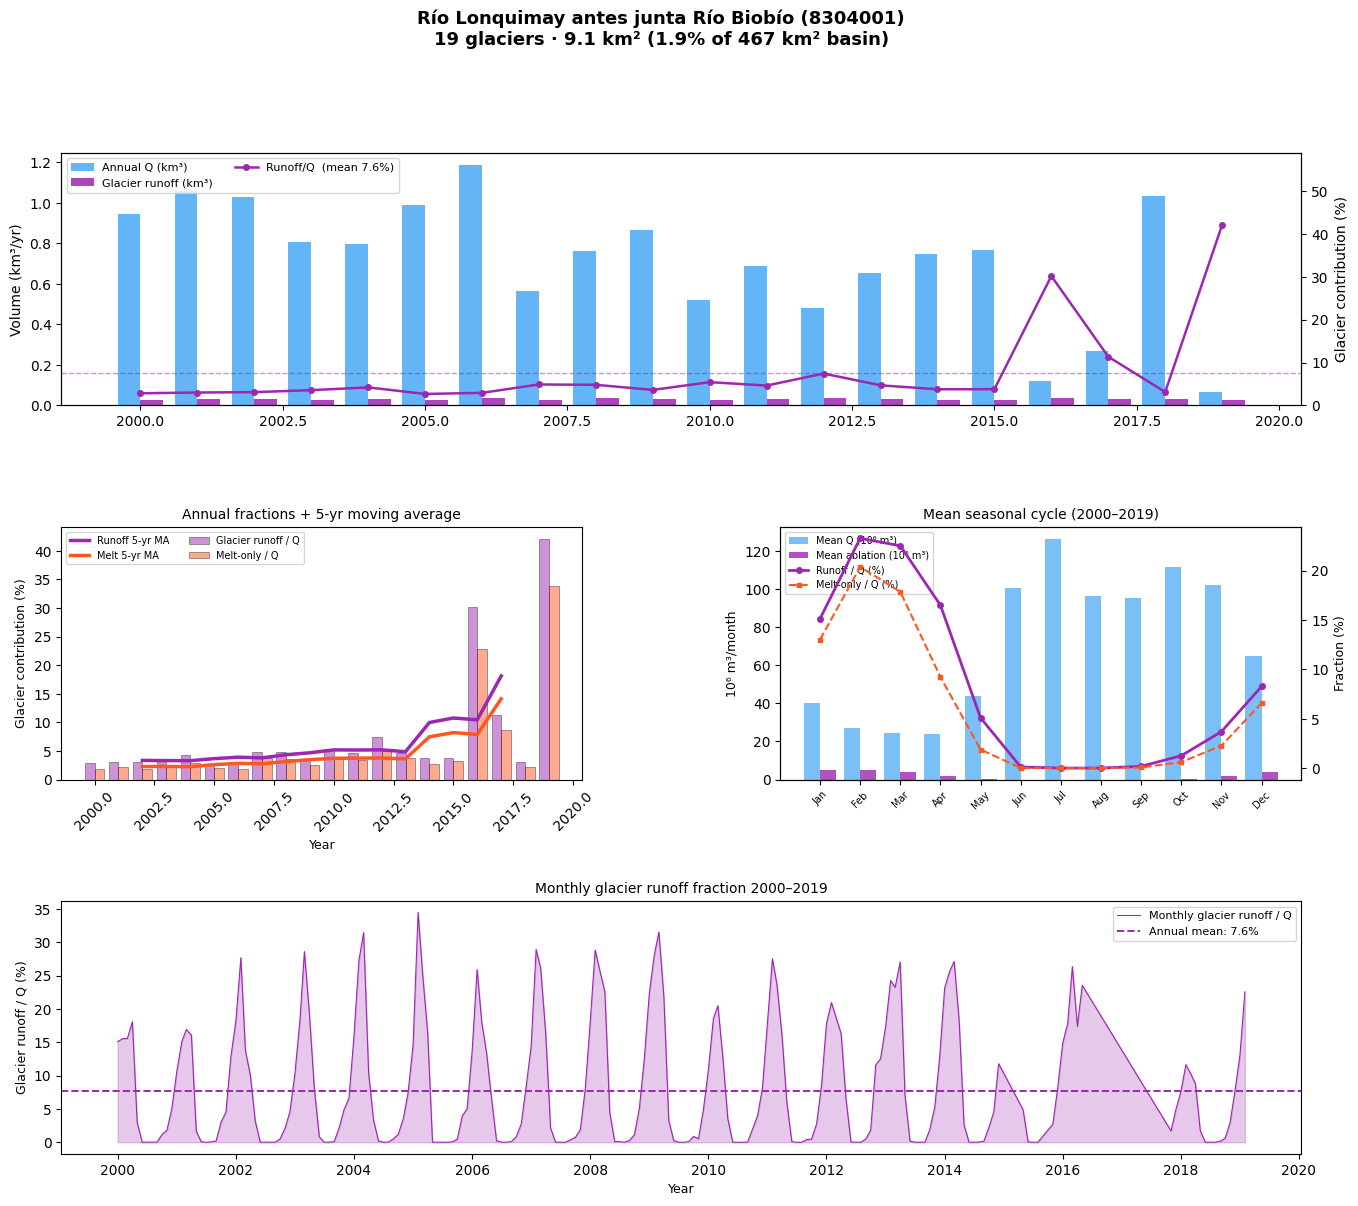

  Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/8304001_glacier_contribution.png


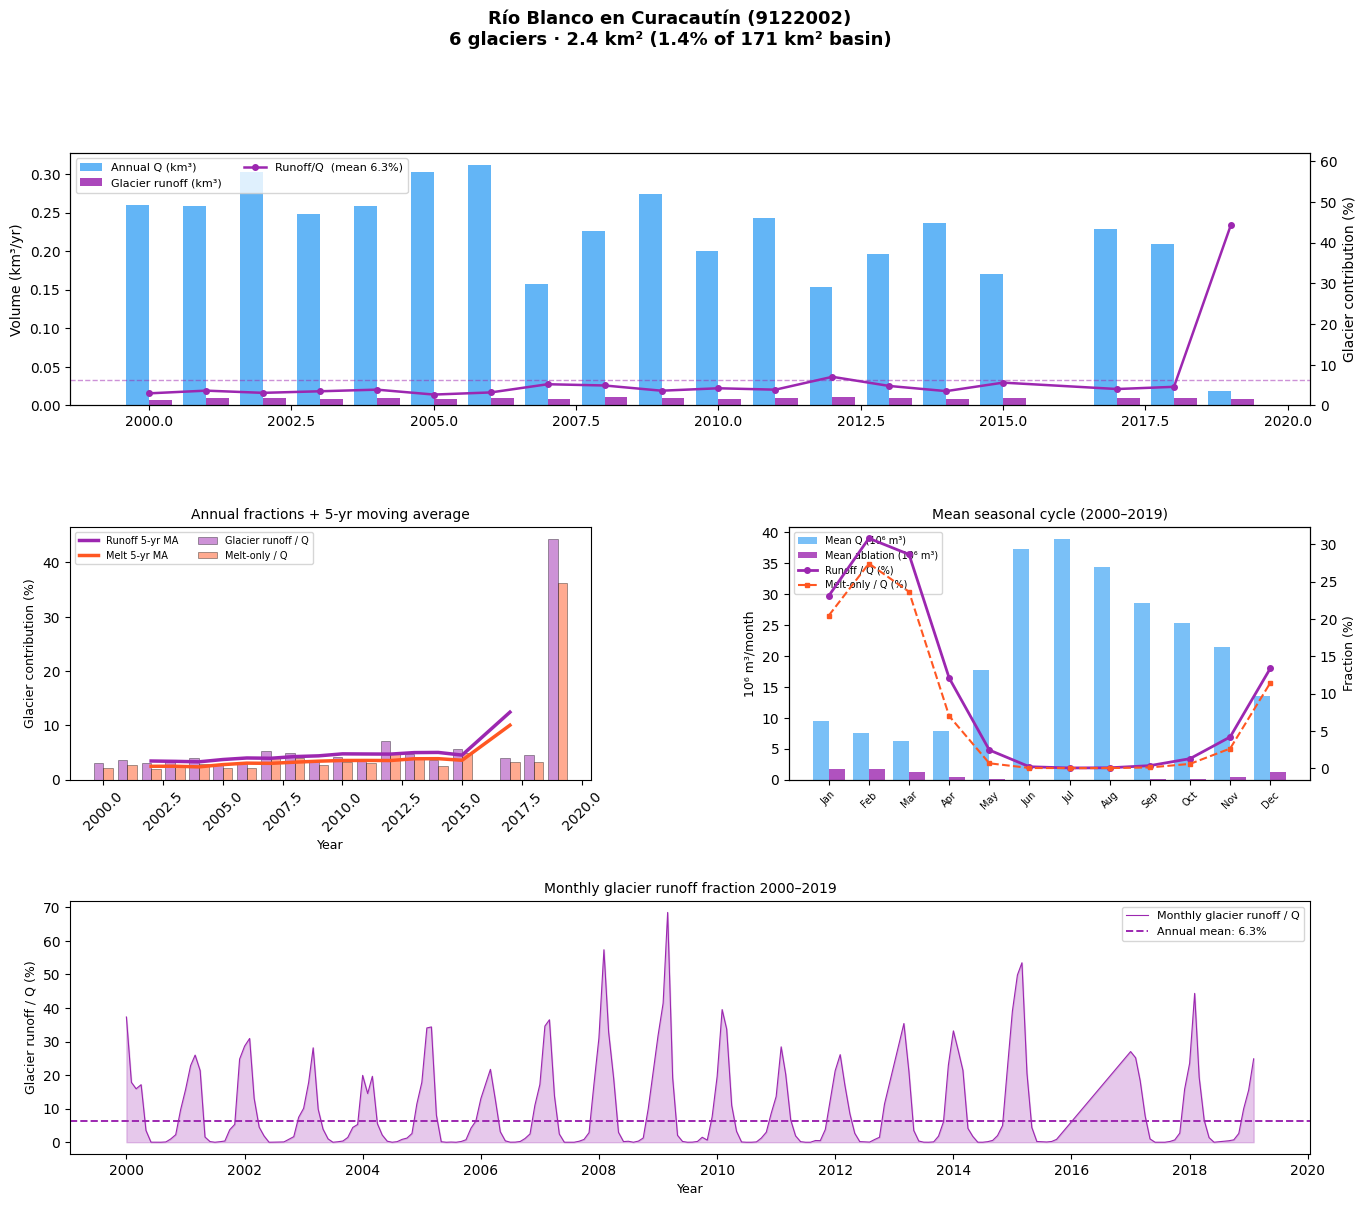

  Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/9122002_glacier_contribution.png


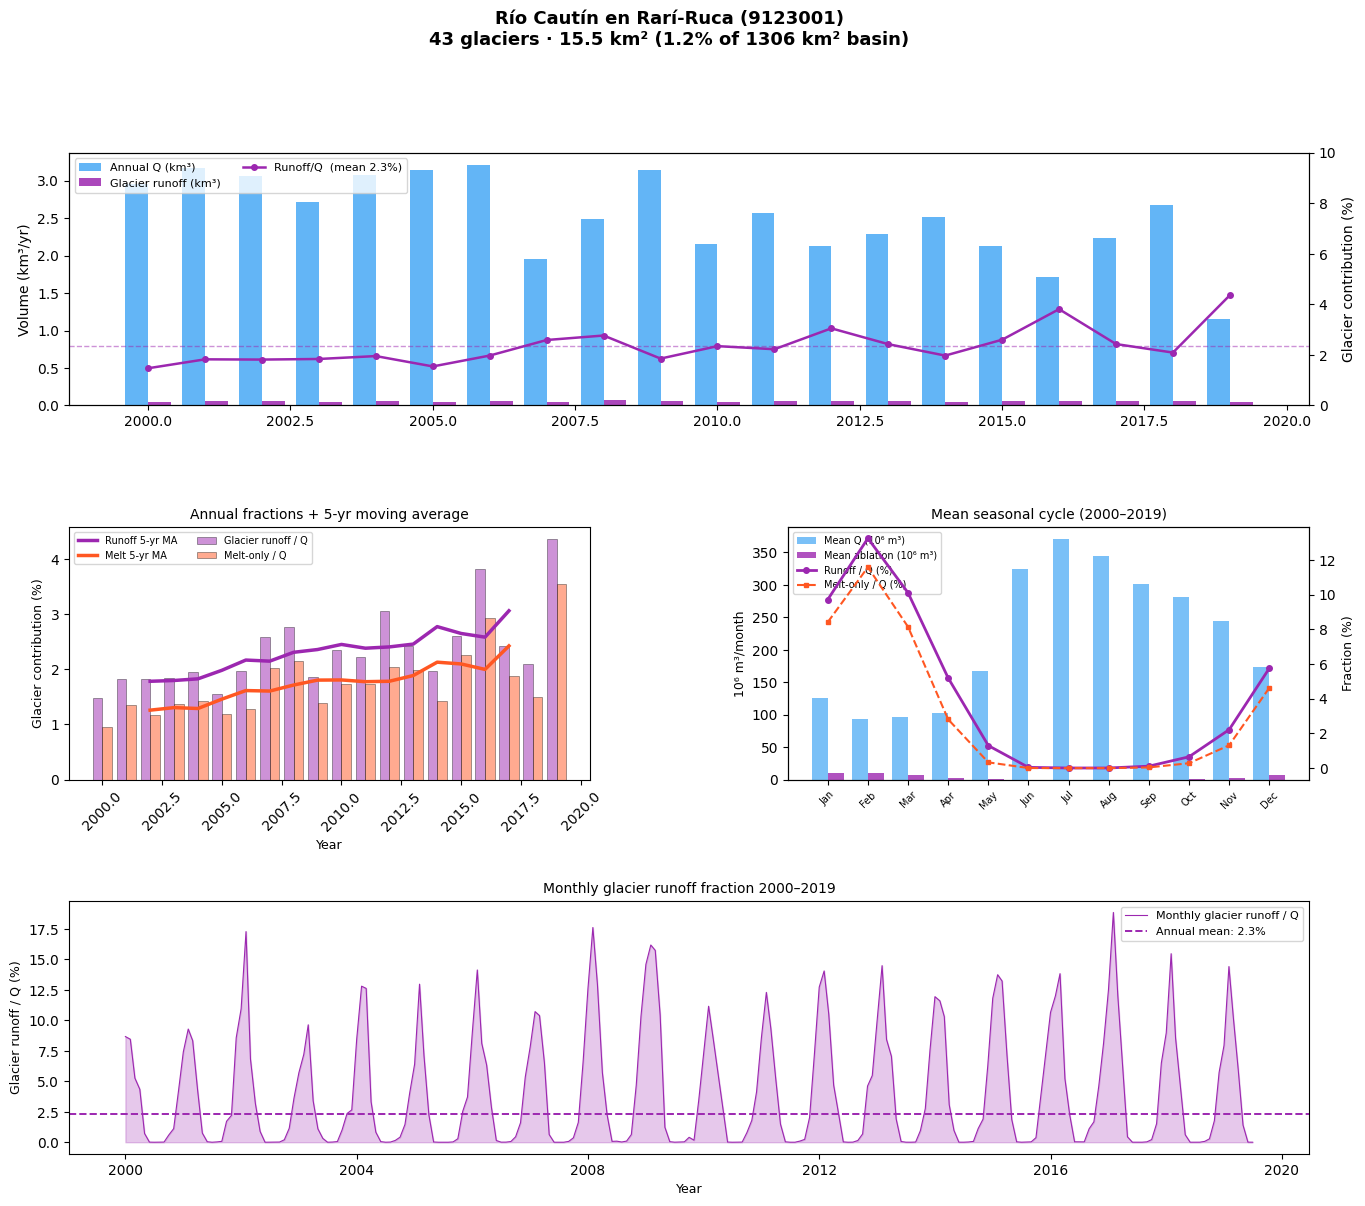

  Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/9123001_glacier_contribution.png


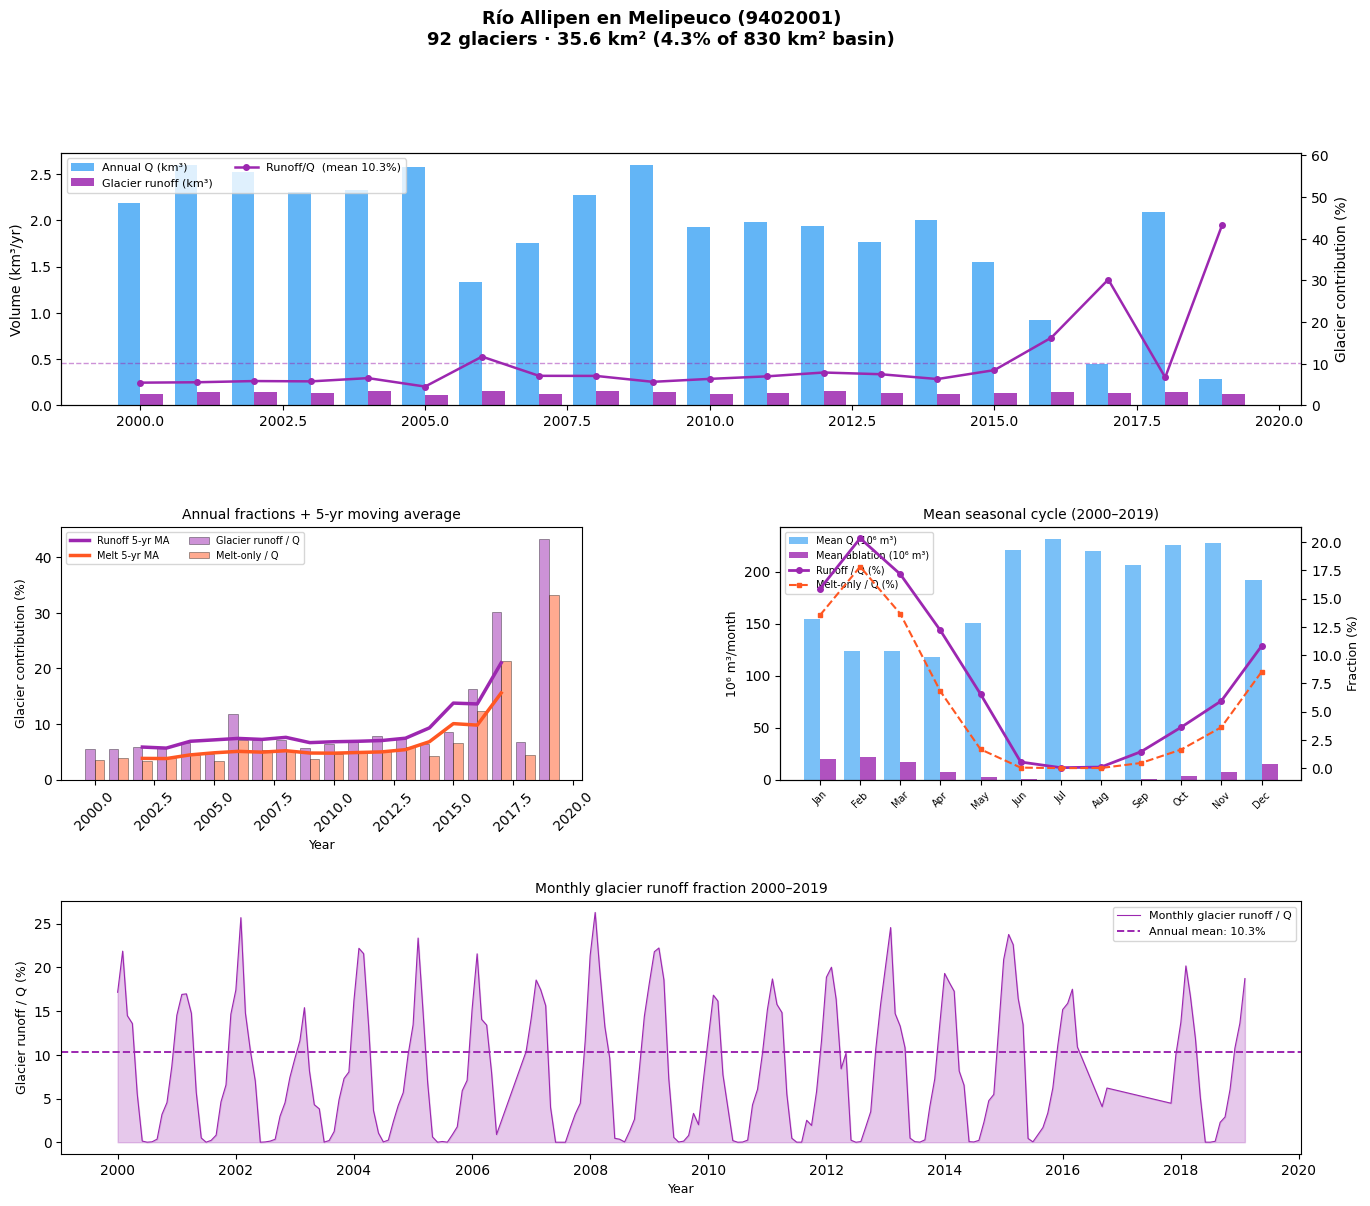

  Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/9402001_glacier_contribution.png


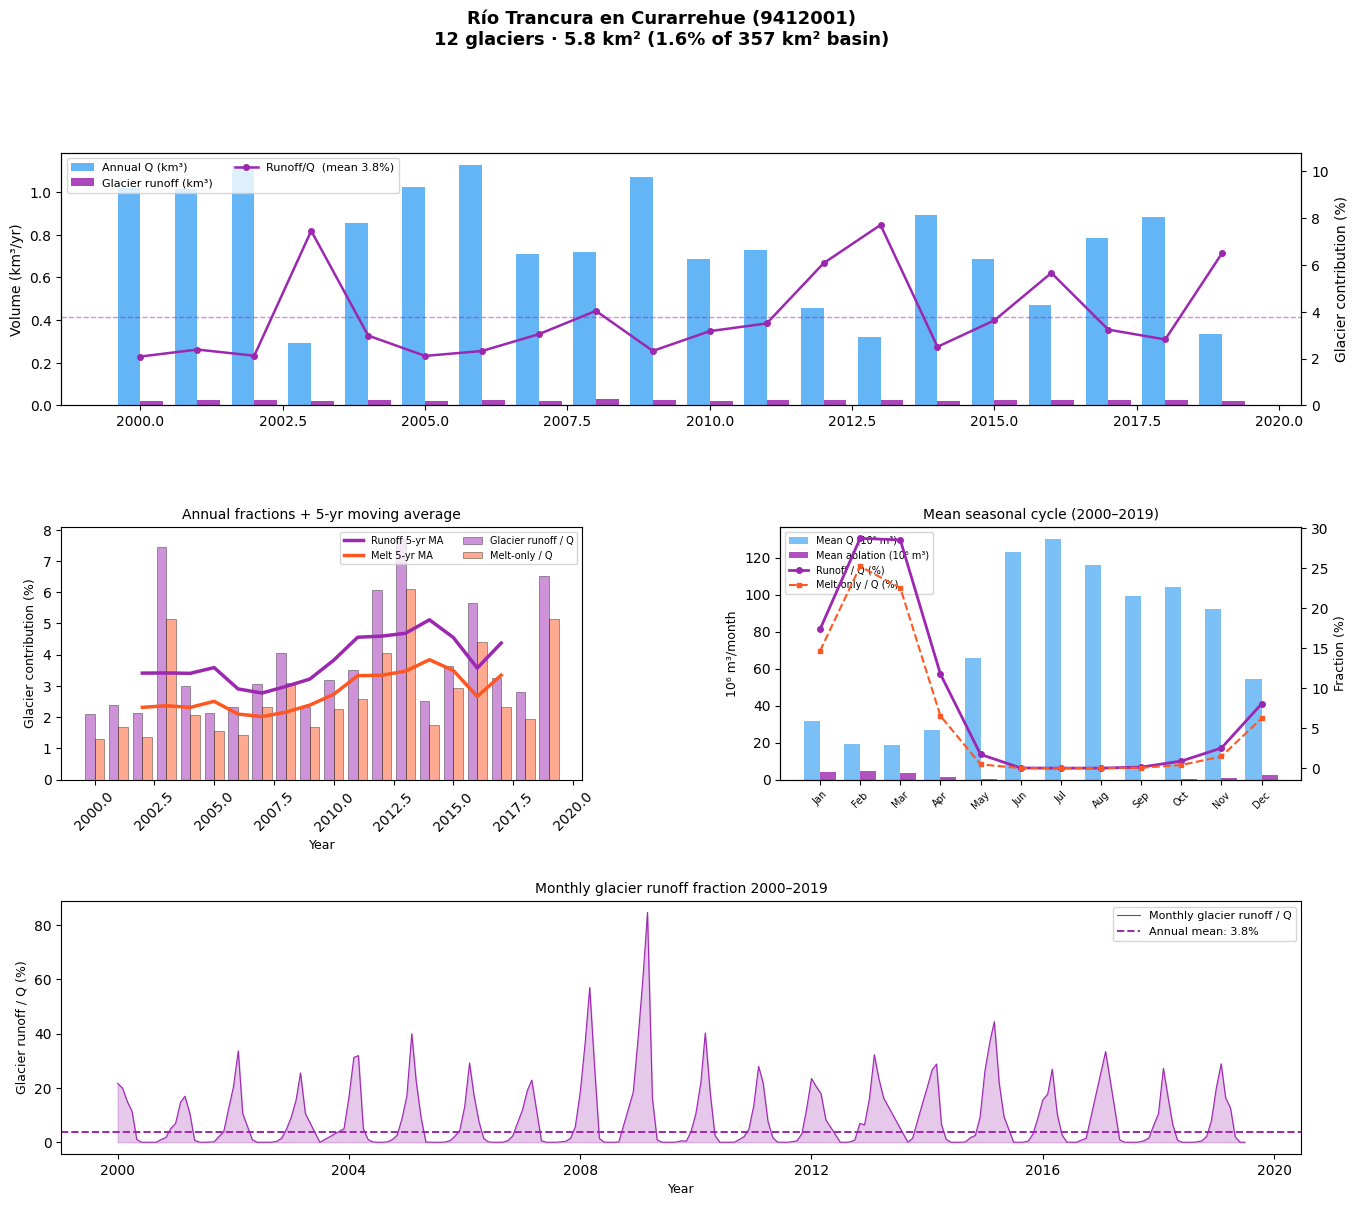

  Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/9412001_glacier_contribution.png


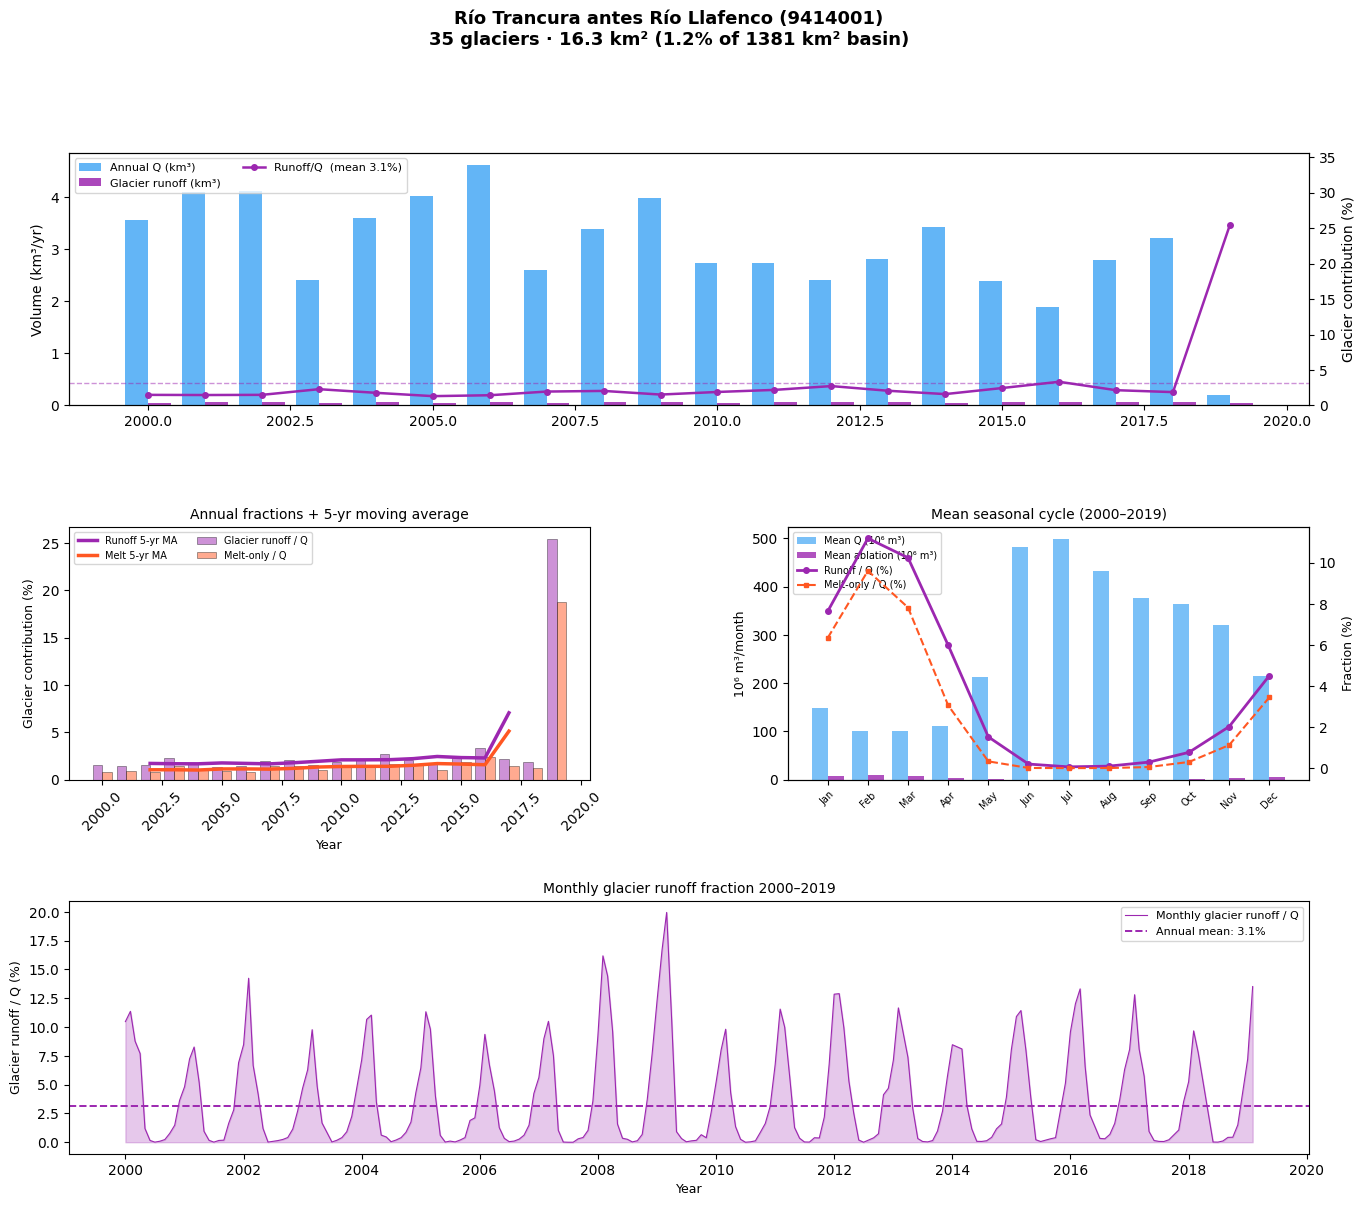

  Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/9414001_glacier_contribution.png


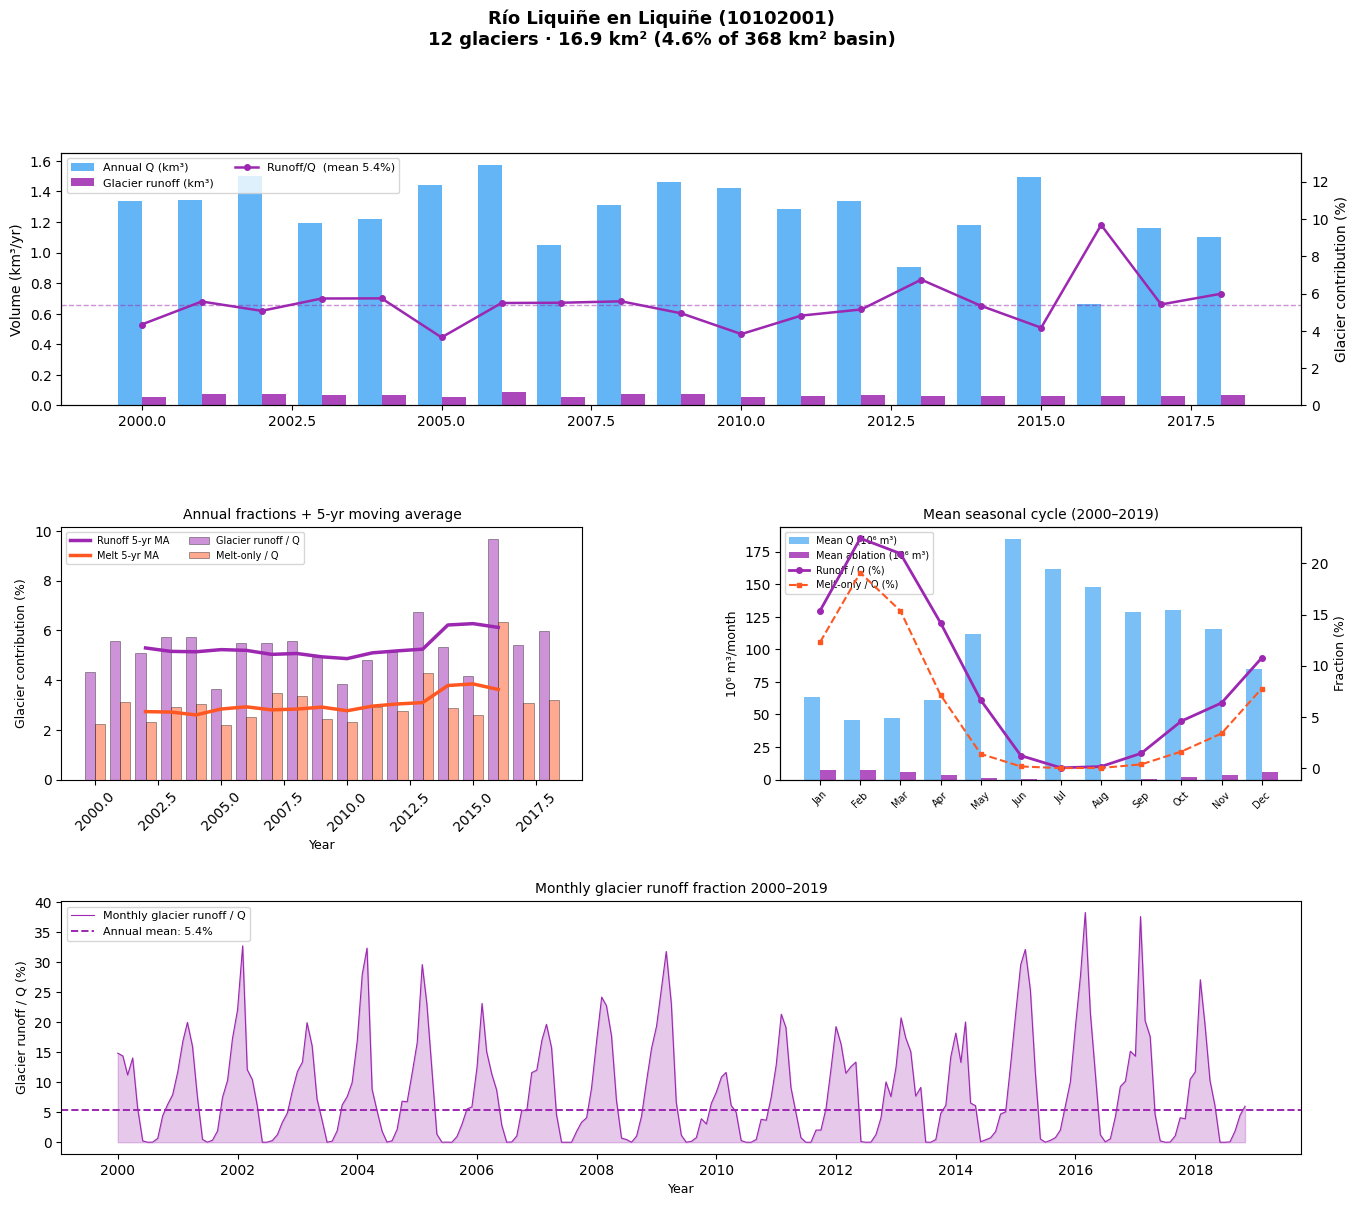

  Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/10102001_glacier_contribution.png


In [9]:
"""Cell 8 — Per-basin 4-panel plot (mirrors Allipen Cell 6)."""

for gauge_id, res in RESULTS.items():
    if res is None:
        continue

    fig = plt.figure(figsize=(16, 13))
    fig.suptitle(
        f'{res["basin_name"]} ({gauge_id})\n'
        f'{res["n_glaciers"]} glaciers · {res["glacier_area_km2"]:.1f} km² '
        f'({res["glacier_pct"]:.1f}% of {res["basin_area_km2"]:.0f} km² basin)',
        fontsize=13, fontweight='bold', y=0.99)

    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.38)
    years = np.array(res['q_annual'].index, dtype=float)

    # ── Panel A (top, full width): Annual Q vs glacier runoff ─────────────
    ax1  = fig.add_subplot(gs[0, :])
    ax1b = ax1.twinx()

    ax1.bar(years - 0.2, res['q_annual']      / 1e9, width=0.4,
            color=C_Q,    alpha=0.7,  label='Annual Q (km³)')
    ax1.bar(years + 0.2, res['runoff_annual'] / 1e9, width=0.4,
            color=C_MELT, alpha=0.85, label='Glacier runoff (km³)')

    ax1b.plot(years, res['frac_runoff_ann'].values, '-o',
              color=C_MELT, ms=4, lw=1.8,
              label=f'Runoff/Q  (mean {res["mean_frac_runoff"]:.1f}%)')
    ax1b.axhline(res['mean_frac_runoff'], ls='--', lw=1, color=C_MELT, alpha=0.5)

    ax1.set_ylabel('Volume (km³/yr)', fontsize=10)
    ax1b.set_ylabel('Glacier contribution (%)', fontsize=10)
    ax1b.set_ylim(0, max(res['frac_runoff_ann'].max() * 1.4, 10))
    l1, lb1 = ax1.get_legend_handles_labels()
    l2, lb2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1+l2, lb1+lb2, fontsize=8, loc='upper left', ncol=2)

    # ── Panel B (mid left): Annual fractions + 5-yr MA ────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.bar(years - 0.2, res['frac_runoff_ann'].values, width=0.4,
            color=C_MELT, alpha=0.5, edgecolor='k', lw=0.5,
            label='Glacier runoff / Q')
    ax2.bar(years + 0.2, res['frac_melt_ann'].values, width=0.4,
            color=C_IMBAL, alpha=0.5, edgecolor='k', lw=0.5,
            label='Melt-only / Q')
    ma_run  = pd.Series(res['frac_runoff_ann'].values, index=years).rolling(5, center=True).mean()
    ma_melt = pd.Series(res['frac_melt_ann'].values,   index=years).rolling(5, center=True).mean()
    ax2.plot(years, ma_run.values,  '-', color=C_MELT,  lw=2.5, label='Runoff 5-yr MA')
    ax2.plot(years, ma_melt.values, '-', color=C_IMBAL, lw=2.5, label='Melt 5-yr MA')
    ax2.set_ylabel('Glacier contribution (%)', fontsize=9)
    ax2.set_xlabel('Year', fontsize=9)
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(fontsize=7, ncol=2)
    ax2.set_title('Annual fractions + 5-yr moving average', fontsize=10)

    # ── Panel C (mid right): Seasonal cycle ───────────────────────────────
    ax3  = fig.add_subplot(gs[1, 1])
    ax3b = ax3.twinx()
    mo   = np.arange(1, 13)
    ax3.bar(mo - 0.2, res['q_seasonal'].values   / 1e6, width=0.4,
            color=C_Q,    alpha=0.6, label='Mean Q (10⁶ m³)')
    ax3.bar(mo + 0.2, res['gl_mon_mean'].values  / 1e6, width=0.4,
            color=C_MELT, alpha=0.8, label='Mean ablation (10⁶ m³)')
    ax3b.plot(mo, res['frac_runoff_seas'].values, '-o',
              color=C_MELT, ms=4, lw=2,    label='Runoff / Q (%)')
    ax3b.plot(mo, res['frac_melt_seas'].values,  '--s',
              color=C_IMBAL, ms=3, lw=1.5, label='Melt-only / Q (%)')
    ax3.set_xticks(mo)
    ax3.set_xticklabels(MONTH_NAMES, fontsize=7, rotation=45)
    ax3.set_ylabel('10⁶ m³/month', fontsize=9)
    ax3b.set_ylabel('Fraction (%)', fontsize=9)
    ax3.set_title('Mean seasonal cycle (2000–2019)', fontsize=10)
    l3a, lb3a = ax3.get_legend_handles_labels()
    l3b, lb3b = ax3b.get_legend_handles_labels()
    ax3.legend(l3a+l3b, lb3a+lb3b, fontsize=7, loc='upper left')

    # ── Panel D (bottom, full width): Monthly fraction timeseries ─────────
    ax4 = fig.add_subplot(gs[2, :])
    ax4.fill_between(res['frac_runoff_mon'].index,
                     res['frac_runoff_mon'].values, alpha=0.25, color=C_MELT)
    ax4.plot(res['frac_runoff_mon'].index, res['frac_runoff_mon'].values,
             lw=0.8, color=C_MELT, label='Monthly glacier runoff / Q')
    ax4.axhline(res['mean_frac_runoff'], ls='--', lw=1.4, color=C_MELT,
                label=f'Annual mean: {res["mean_frac_runoff"]:.1f}%')
    ax4.set_ylabel('Glacier runoff / Q (%)', fontsize=9)
    ax4.set_xlabel('Year', fontsize=9)
    ax4.set_title('Monthly glacier runoff fraction 2000–2019', fontsize=10)
    ax4.legend(fontsize=8)

    out = f'{OUT_DIR}/{gauge_id}_glacier_contribution.png'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out}')

8304001 Feb: mean=23.3%  max=34.5% (2005)


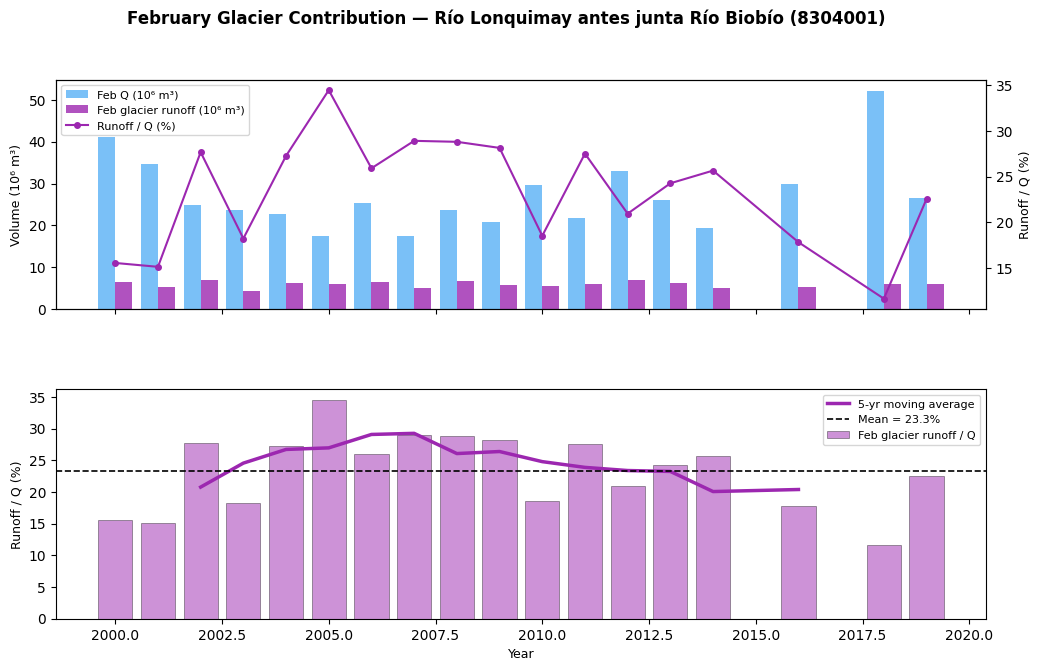

9122002 Feb: mean=30.8%  max=57.4% (2008)


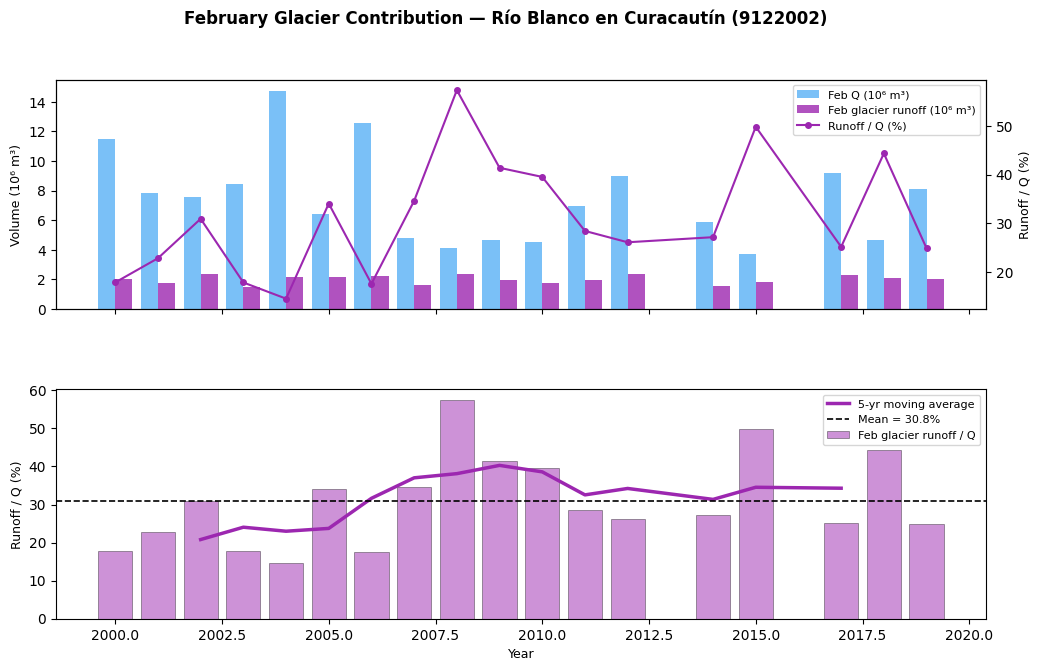

9123001 Feb: mean=13.2%  max=18.9% (2017)


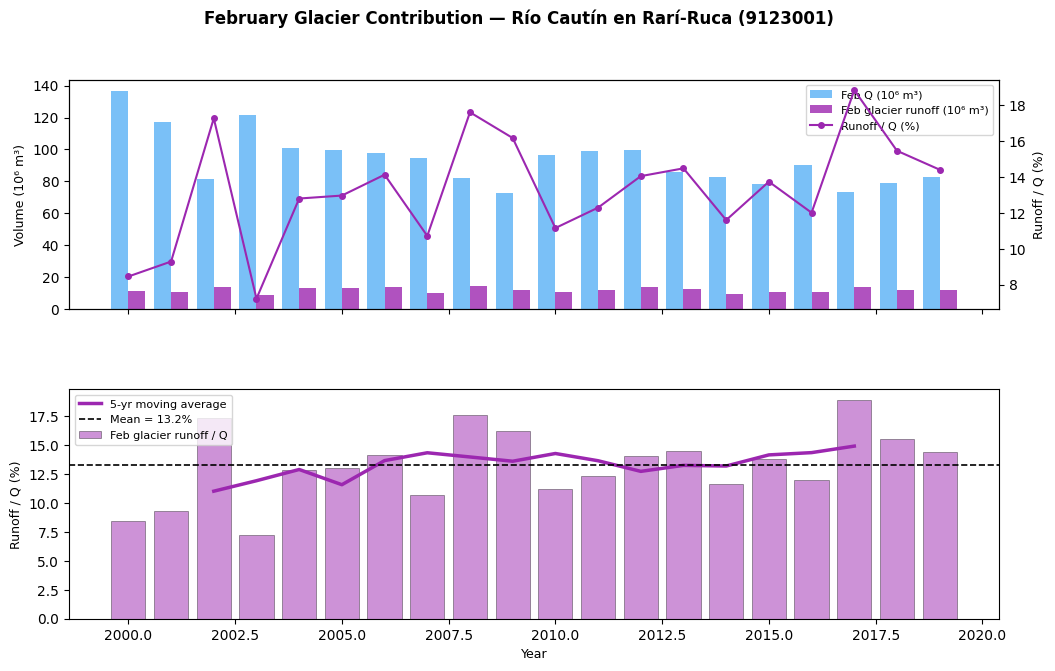

9402001 Feb: mean=20.3%  max=26.3% (2008)


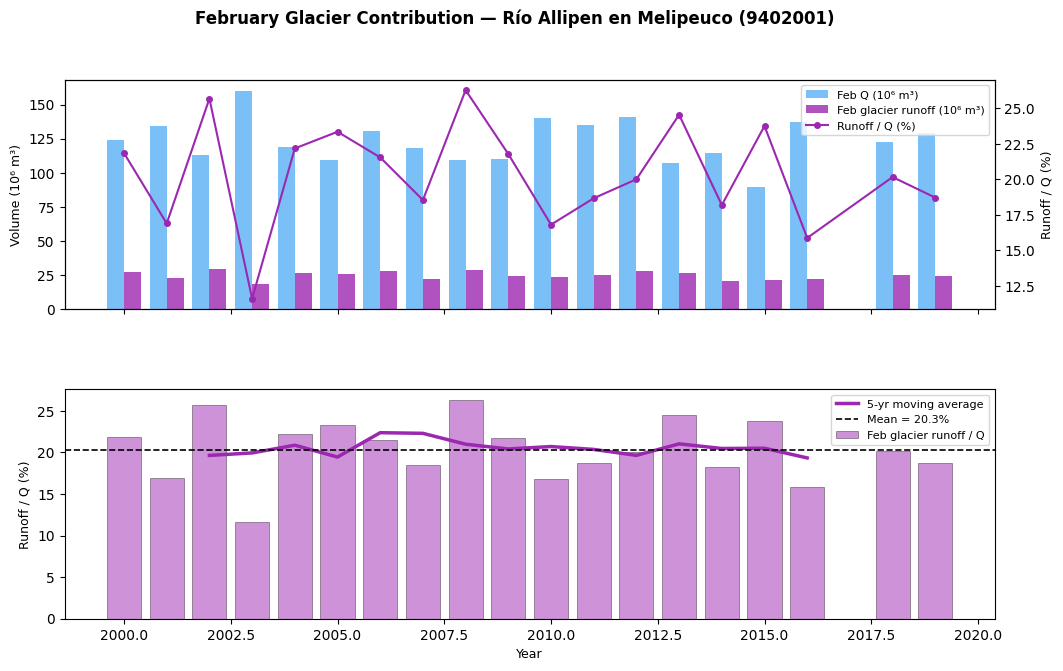

9412001 Feb: mean=28.7%  max=61.1% (2009)


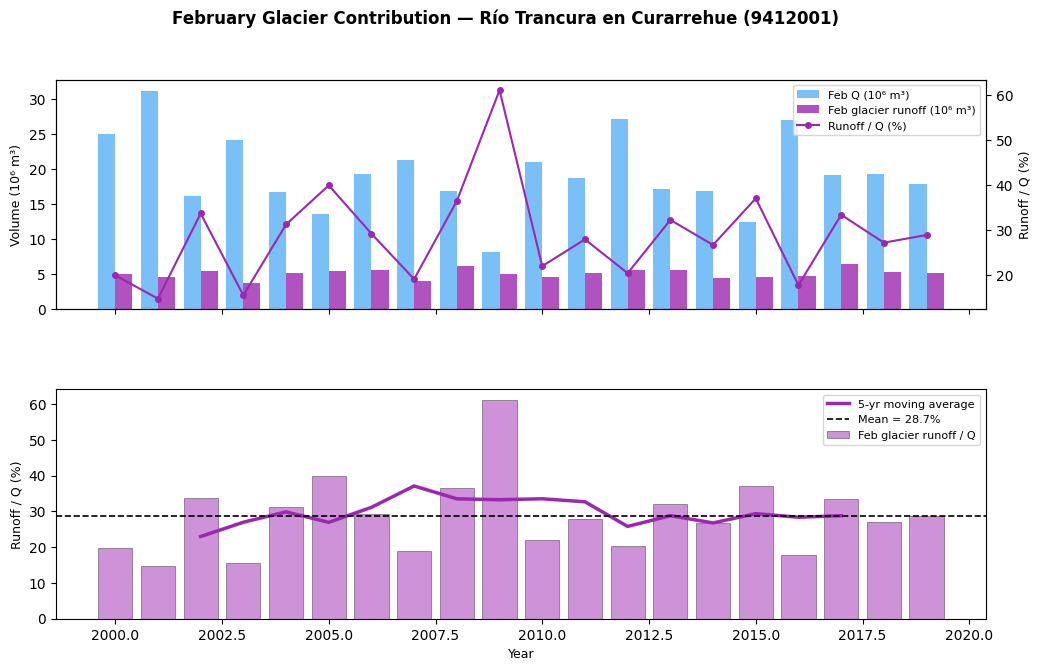

9414001 Feb: mean=11.2%  max=16.7% (2009)


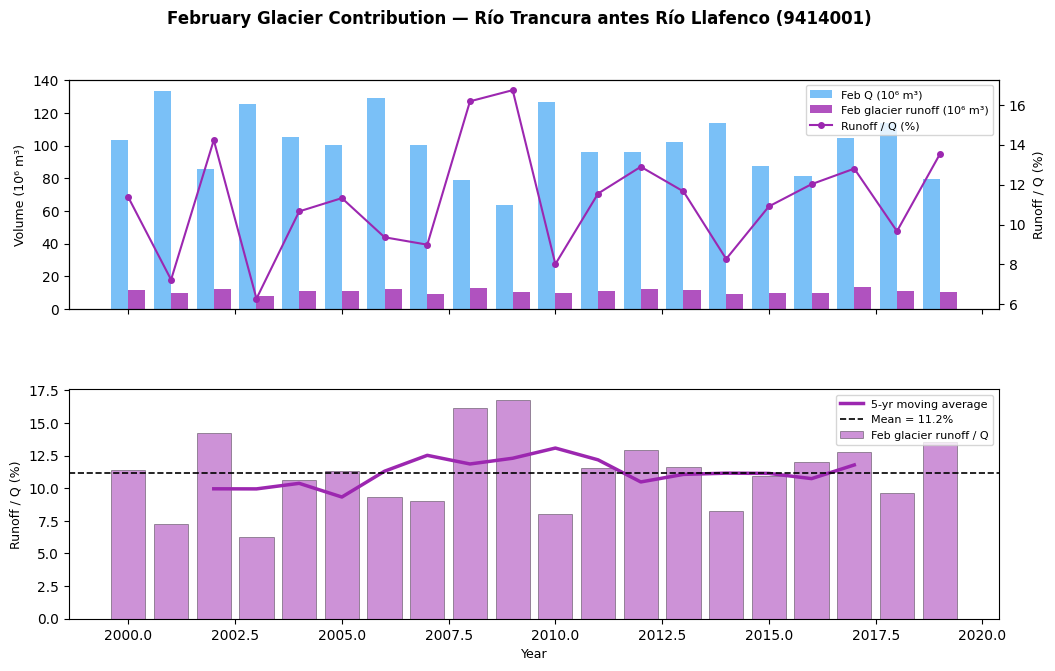

10102001 Feb: mean=22.4%  max=37.6% (2017)


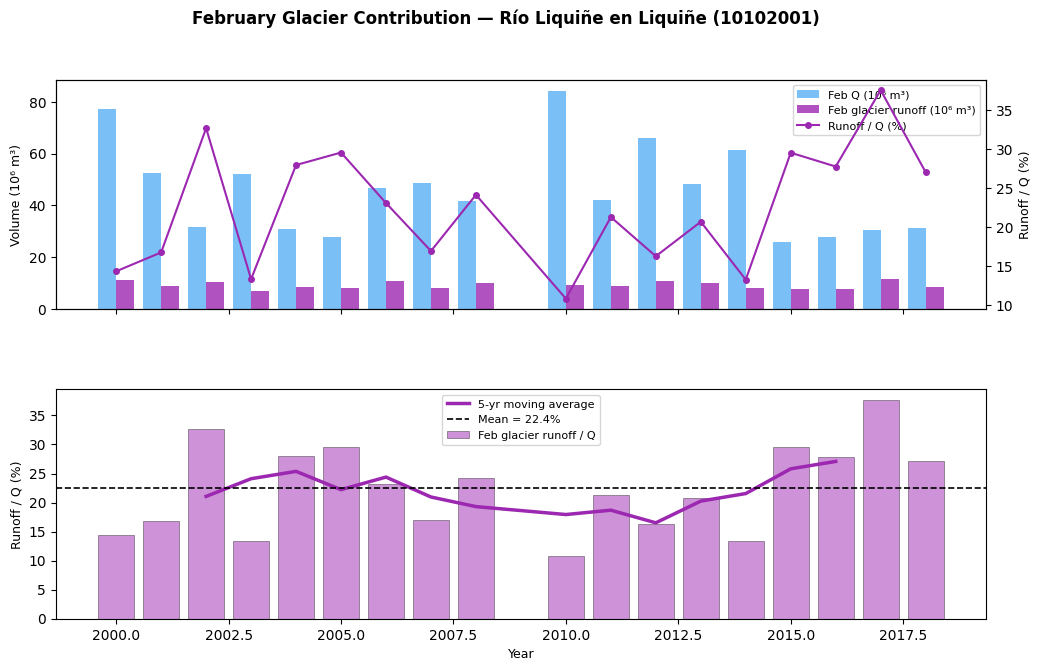

In [10]:
"""Cell 9 — February contribution plot per basin (mirrors Allipen Cell 6b)."""

for gauge_id, res in RESULTS.items():
    if res is None:
        continue

    frac_mon = res['frac_runoff_mon']
    feb_mask = frac_mon.index.month == 2
    feb_frac = frac_mon[feb_mask]
    feb_q    = res['q_monthly'][feb_mask]
    feb_run  = res['runoff_monthly'][feb_mask]
    feb_yrs  = feb_frac.index.year

    if len(feb_frac) < 3:
        print(f'{gauge_id}: insufficient February data — skipping')
        continue

    feb_ma = pd.Series(feb_frac.values, index=feb_yrs).rolling(5, center=True).mean()

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(
        f'February Glacier Contribution — {res["basin_name"]} ({gauge_id})',
        fontsize=12, fontweight='bold')
    fig.subplots_adjust(hspace=0.35)

    ax1  = axes[0]
    ax1b = ax1.twinx()
    ax1.bar(feb_yrs - 0.2, feb_q   / 1e6, width=0.4,
            color=C_Q,    alpha=0.6, label='Feb Q (10⁶ m³)')
    ax1.bar(feb_yrs + 0.2, feb_run / 1e6, width=0.4,
            color=C_MELT, alpha=0.8, label='Feb glacier runoff (10⁶ m³)')
    ax1b.plot(feb_yrs, feb_frac.values, '-o',
              color=C_MELT, ms=4, lw=1.5, label='Runoff / Q (%)')
    ax1.set_ylabel('Volume (10⁶ m³)', fontsize=9)
    ax1b.set_ylabel('Runoff / Q (%)',  fontsize=9)
    l1, lb1 = ax1.get_legend_handles_labels()
    l2, lb2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1+l2, lb1+lb2, fontsize=8)

    ax2 = axes[1]
    ax2.bar(feb_yrs, feb_frac.values, color=C_MELT, alpha=0.5,
            edgecolor='k', lw=0.5, label='Feb glacier runoff / Q')
    ax2.plot(feb_yrs, feb_ma.values, '-', color=C_MELT, lw=2.5,
             label='5-yr moving average')
    ax2.axhline(feb_frac.mean(), ls='--', lw=1.2, color='k',
                label=f'Mean = {feb_frac.mean():.1f}%')
    ax2.set_ylabel('Runoff / Q (%)', fontsize=9)
    ax2.set_xlabel('Year', fontsize=9)
    ax2.legend(fontsize=8)

    print(f'{gauge_id} Feb: mean={feb_frac.mean():.1f}%  '
          f'max={feb_frac.max():.1f}% ({feb_yrs[feb_frac.values.argmax()]})')

    out = f'{OUT_DIR}/{gauge_id}_february_contribution.png'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()

In [11]:
"""Cell 10 — Annual + seasonal tables per basin; combined CSV."""

all_rows = []

for gauge_id, res in RESULTS.items():
    if res is None:
        continue

    print(f'\n── {gauge_id}: {res["basin_name"]} ──────────────────────────────────────')

    ann_df = pd.DataFrame({
        'Q_km3':        (res['q_annual']      / 1e9).round(4),
        'Ablation_km3': (res['melt_annual']   / 1e9).round(4),
        'Runoff_km3':   (res['runoff_annual'] / 1e9).round(4),
        'Ablation_pct': res['frac_melt_ann'].round(2),
        'Runoff_pct':   res['frac_runoff_ann'].round(2),
    })
    print(ann_df.to_string())

    # .values strips the integer month index so MONTH_NAMES aligns correctly
    seas_df = pd.DataFrame({
        'Mean_Q_m3':     res['q_seasonal'].values,
        'Runoff_m3':     res['runoff_seasonal'].values,
        'Runoff_pct':    res['frac_runoff_seas'].values,
        'Melt_only_pct': res['frac_melt_seas'].values,
    }, index=MONTH_NAMES)
    print('\nSeasonal means (2000–2019):')
    print(seas_df.round(2).to_string())

    print(f'\nKey stats:')
    print(f'  Basin area   : {res["basin_area_km2"]:.0f} km²')
    print(f'  Glacier area : {res["glacier_area_km2"]:.1f} km²  ({res["glacier_pct"]:.1f}%)')
    print(f'  N glaciers   : {res["n_glaciers"]}')
    print(f'  Runoff/Q     : {res["mean_frac_runoff"]:.1f}%  '
          f'(max {res["max_frac_runoff"]:.1f}% in {res["max_frac_year"]})')
    print(f'  Melt-only/Q  : {res["mean_frac_melt"]:.1f}%')
    print(f'  Peak month   : {MONTH_NAMES[res["frac_runoff_seas"].values.argmax()]} '
          f'({res["frac_runoff_seas"].values.max():.1f}%)')

    for yr, row in ann_df.iterrows():
        all_rows.append({'gauge_id': gauge_id,
                         'basin_name': res['basin_name'],
                         'year': yr,
                         **row.to_dict()})

all_df = pd.DataFrame(all_rows)
out_csv = f'{OUT_DIR}/all_basins_annual.csv'
all_df.to_csv(out_csv, index=False)
print(f'\n✓ Combined annual CSV: {out_csv}')


── 8304001: Río Lonquimay antes junta Río Biobío ──────────────────────────────────────
       Q_km3  Ablation_km3  Runoff_km3  Ablation_pct  Runoff_pct
2000  0.9435        0.0174      0.0268          1.85        2.85
2001  1.0575        0.0231      0.0320          2.18        3.02
2002  1.0298        0.0196      0.0321          1.90        3.11
2003  0.8045        0.0205      0.0288          2.55        3.57
2004  0.7973        0.0233      0.0336          2.92        4.22
2005  0.9874        0.0199      0.0266          2.01        2.69
2006  1.1877        0.0223      0.0350          1.88        2.95
2007  0.5666        0.0212      0.0278          3.73        4.90
2008  0.7617        0.0277      0.0367          3.63        4.82
2009  0.8677        0.0225      0.0315          2.59        3.63
2010  0.5211        0.0207      0.0283          3.98        5.44
2011  0.6888        0.0241      0.0320          3.49        4.65
2012  0.4788        0.0237      0.0357          4.94        7.45
2

In [12]:
"""Summary cell — rank basins by glacier % of basin area."""

from scipy.stats import linregress

rows = []
for gauge_id, res in RESULTS.items():
    if res is None:
        continue

    frac   = res['frac_runoff_ann']
    q      = res['q_annual']
    runoff = res['runoff_annual']
    melt   = res['melt_annual']
    area   = res['area_annual'].loc[2000:2019]  # m²

    # ── Linear trend in glacier fraction ─────────────────────────────────
    slope, _, _, p_val, _ = linregress(frac.index.astype(float), frac.values)

    # ── February mean ─────────────────────────────────────────────────────
    frac_mon = res['frac_runoff_mon']
    feb_mean = frac_mon[frac_mon.index.month == 2].mean()

    # ── Buffering ratio ───────────────────────────────────────────────────
    common          = q.index.intersection(runoff.index)
    cv_q            = q.loc[common].std()      / q.loc[common].mean()      * 100
    cv_runoff       = runoff.loc[common].std() / runoff.loc[common].mean() * 100
    buffering_ratio = cv_q / cv_runoff

    # ── Period means ──────────────────────────────────────────────────────
    mean_2000_2009      = frac.loc[2000:2009].mean()
    mean_2010_2019      = frac.loc[2010:2019].mean()
    mean_2015_2019      = frac.loc[2015:2019].mean()
    change_2010_vs_2000 = mean_2010_2019 - mean_2000_2009
    change_2015_vs_2000 = mean_2015_2019 - mean_2000_2009

    # ── Glacier area change 2000–2019 ─────────────────────────────────────
    area_2000     = area.loc[2000] / 1e6  # km²
    area_2019     = area.loc[2019] / 1e6
    area_loss_pct = (area_2000 - area_2019) / area_2000 * 100

    # ── Melt intensity: melt volume / contemporaneous area → mm w.e./yr ──
    # Separates melt rate per unit area from shrinkage effect
    common_area   = melt.index.intersection(area.index)
    melt_intensity = (melt.loc[common_area] /
                      area.loc[common_area]) * 1000  # mm w.e./yr
    melt_int_2000_2009 = melt_intensity.loc[2000:2009].mean()
    melt_int_2010_2019 = melt_intensity.loc[2010:2019].mean()
    melt_int_change    = melt_int_2010_2019 - melt_int_2000_2009

    rows.append({
        'Basin':                                          res['basin_name'],
        '% basin is glacier':                             res['glacier_pct'],
        'Glacier area (km2)':                             res['glacier_area_km2'],
        'Basin area (km2)':                               res['basin_area_km2'],
        '% streamflow from glaciers (mean 2000-2019)':    res['mean_frac_runoff'],
        '% streamflow from glaciers (max single year)':   res['max_frac_runoff'],
        'Year of max':                                    res['max_frac_year'],
        'Buffering ratio CV(Q)/CV(glacier runoff)':       buffering_ratio,
        '% streamflow from glaciers (mean Feb)':          feb_mean,
        'Peak month':                                     MONTH_NAMES[res['frac_runoff_seas'].values.argmax()],
        '% streamflow from glaciers (2000-2009)':         mean_2000_2009,
        '% streamflow from glaciers (2010-2019)':         mean_2010_2019,
        '% streamflow from glaciers (2015-2019)':         mean_2015_2019,
        'Change 2010-2019 vs 2000-2009 (pp)':             change_2010_vs_2000,
        'Change 2015-2019 vs 2000-2009 (pp)':             change_2015_vs_2000,
        'Linear trend (%/yr)':                            slope,
        'Trend p<0.05':                                   '*' if p_val < 0.05 else '',
        'Glacier area 2000 (km2)':                        area_2000,
        'Glacier area 2019 (km2)':                        area_2019,
        '% glacier area lost 2000-2019':                  area_loss_pct,
        'Melt intensity 2000-2009 (mm we/yr)':            melt_int_2000_2009,
        'Melt intensity 2010-2019 (mm we/yr)':            melt_int_2010_2019,
        'Change in melt intensity 2010-2019 vs 2000-2009 (mm we/yr)': melt_int_change,
    })

df_summary = pd.DataFrame(rows).sort_values('% basin is glacier', ascending=False)
print(df_summary.round(2).to_string(index=False))

out = f'{OUT_DIR}/basin_ranked_summary.csv'
df_summary.round(3).to_csv(out, index=False)
print(f'\nSaved: {out}')

                               Basin  % basin is glacier  Glacier area (km2)  Basin area (km2)  % streamflow from glaciers (mean 2000-2019)  % streamflow from glaciers (max single year)  Year of max  Buffering ratio CV(Q)/CV(glacier runoff)  % streamflow from glaciers (mean Feb) Peak month  % streamflow from glaciers (2000-2009)  % streamflow from glaciers (2010-2019)  % streamflow from glaciers (2015-2019)  Change 2010-2019 vs 2000-2009 (pp)  Change 2015-2019 vs 2000-2009 (pp)  Linear trend (%/yr) Trend p<0.05  Glacier area 2000 (km2)  Glacier area 2019 (km2)  % glacier area lost 2000-2019  Melt intensity 2000-2009 (mm we/yr)  Melt intensity 2010-2019 (mm we/yr)  Change in melt intensity 2010-2019 vs 2000-2009 (mm we/yr)
              Río Liquiñe en Liquiñe                4.58               16.87            368.06                                         5.41                                          9.67         2016                                      1.41                            

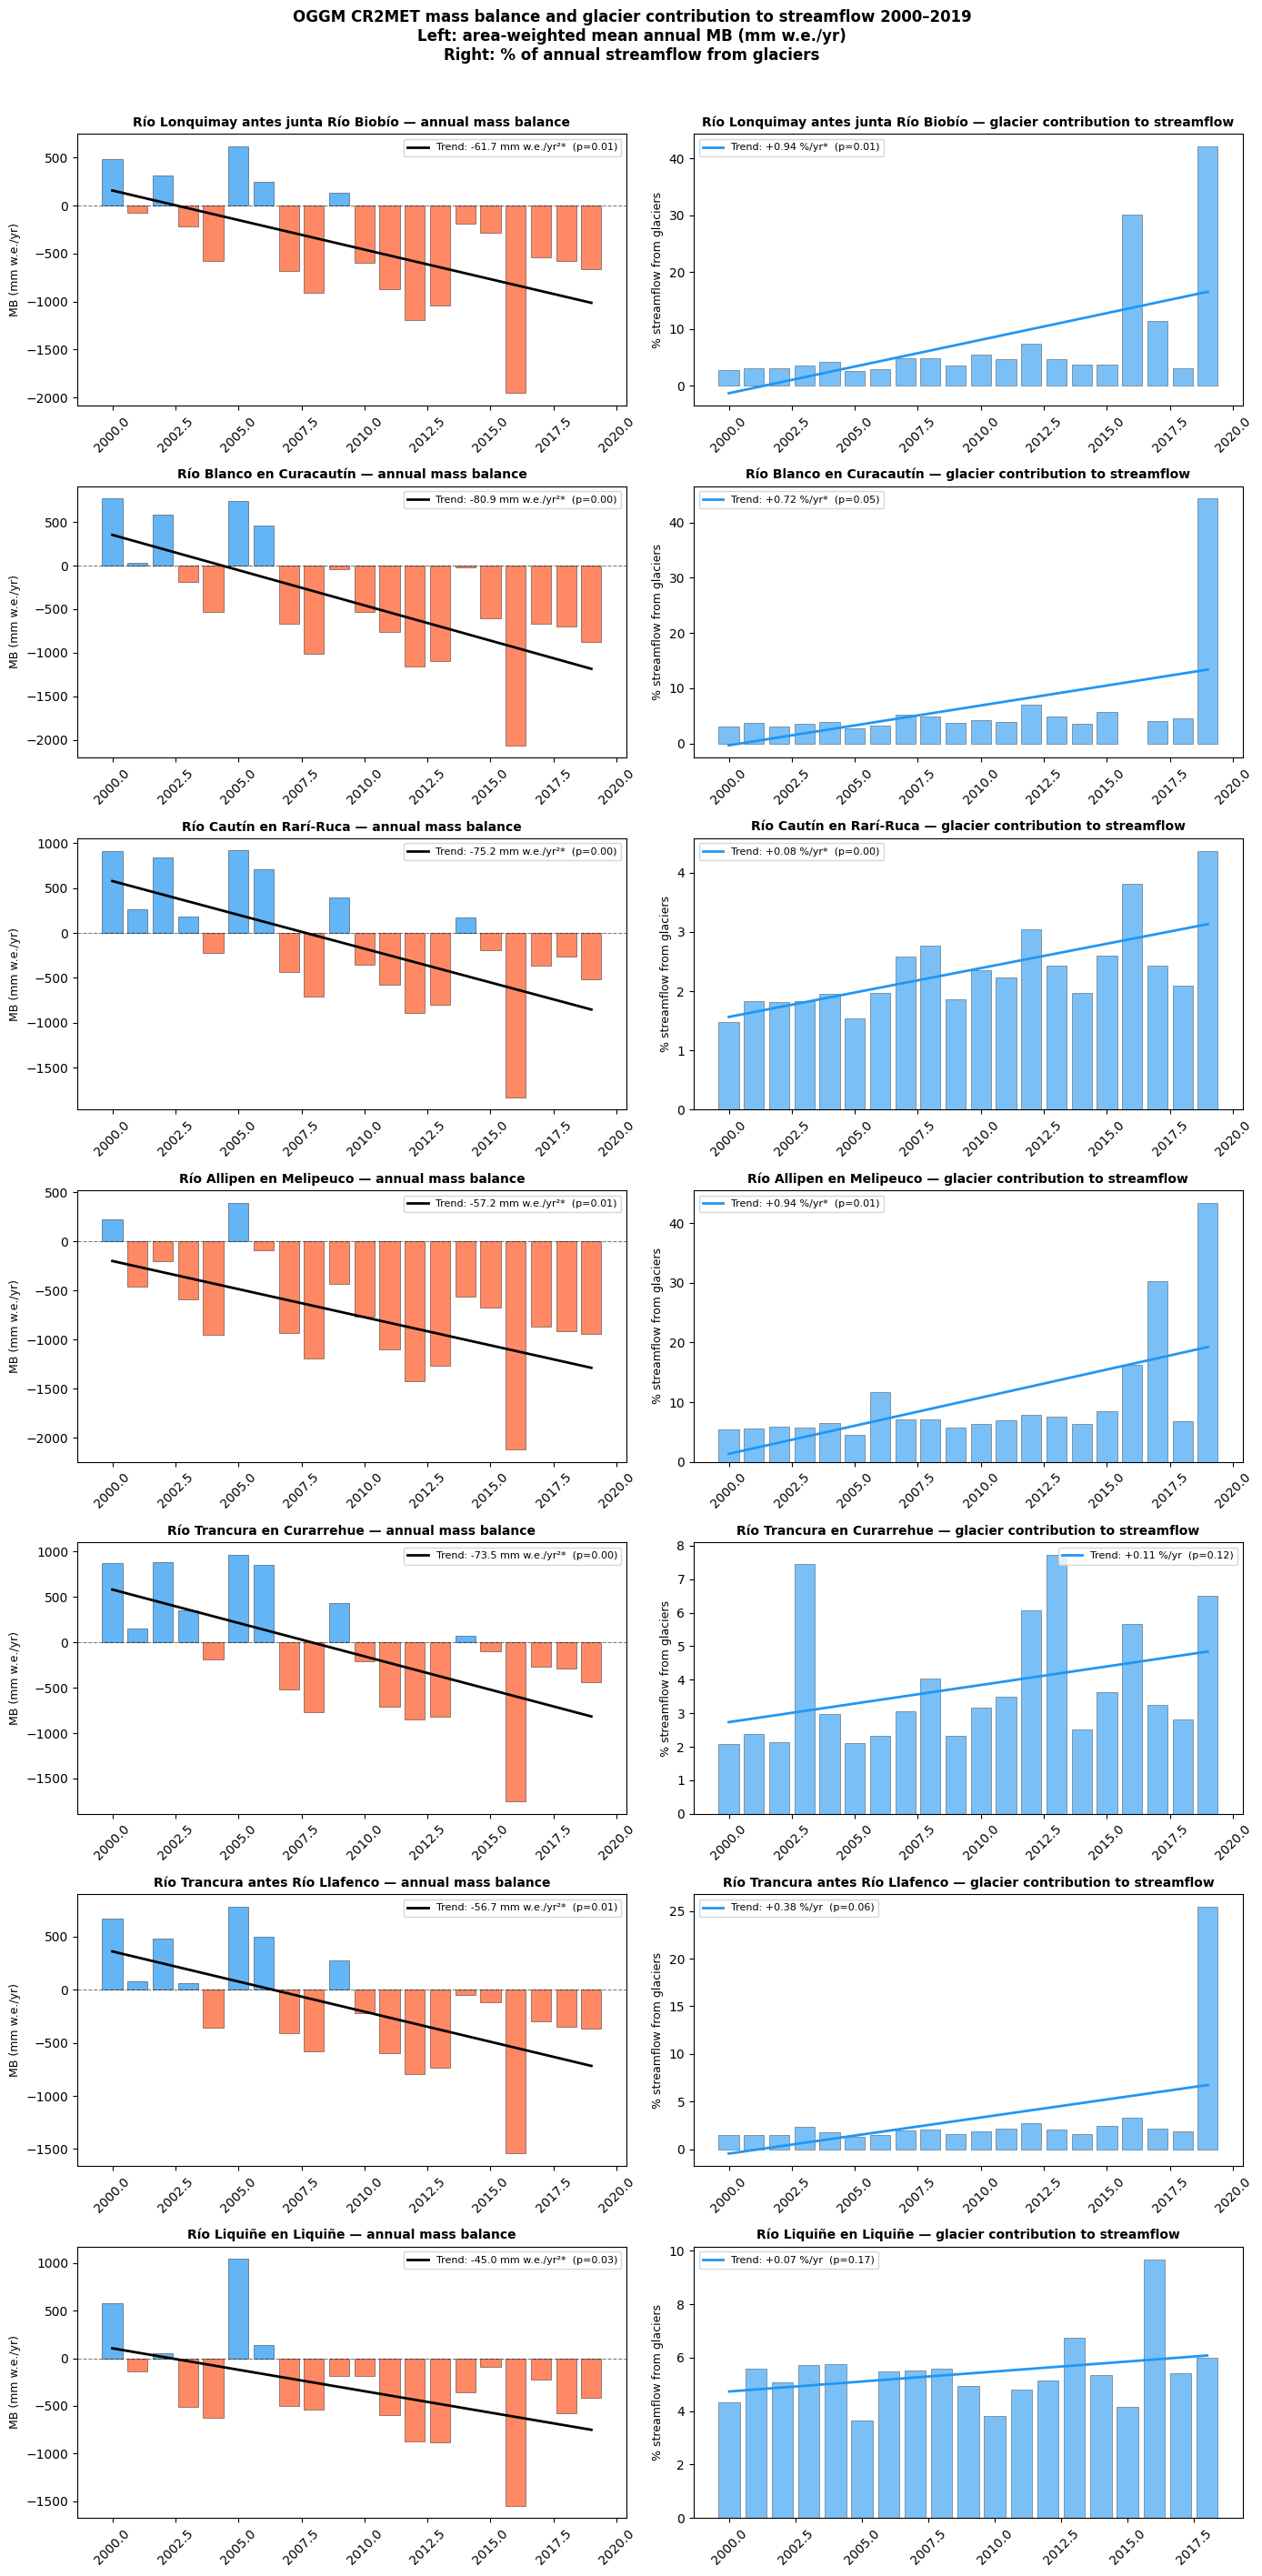

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/mb_vs_fraction_trends.png


In [13]:
"""Plot: OGGM CR2MET annual MB vs glacier contribution fraction, 2000-2019, per basin."""

from scipy.stats import linregress
from oggm import utils
geodetic_ref = utils.get_geodetic_mb_dataframe()
geodetic_ref = geodetic_ref[geodetic_ref['period'] == '2000-01-01_2020-01-01']

MB_BASE = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET'

def load_basin_mb_timeseries(gauge_id):
    """
    Load annual MB timeseries (mm w.e./yr) for all glaciers in a basin,
    compute area-weighted mean across years 2000-2019.
    Returns pd.Series with integer year index.
    """
    basin_rgis = set(GAUGE_INFO[gauge_id]['rgi_ids'])
    clusters   = GAUGE_INFO[gauge_id]['clusters']

    all_mb     = []   # each entry: (n_glaciers, 20) array
    all_areas  = []   # each entry: (n_glaciers,) array
    year_cols  = None

    for cluster in clusters:
        mb_path = f'{MB_BASE}/{cluster}/mb.csv'
        if not os.path.exists(mb_path):
            print(f'  WARNING: {mb_path} not found')
            continue

        mb_df = pd.read_csv(mb_path).set_index('rgi_id')
        matched = [g for g in mb_df.index if g in basin_rgis]
        if len(matched) == 0:
            continue

        if year_cols is None:
            year_cols = mb_df.columns[:20]  # 2000–2019

        mb_vals = mb_df.loc[matched, year_cols].values.astype(float)  # (n_gl, 20)

        # Get areas from geodetic_ref if available, else use equal weights
        areas = np.array([
            geodetic_ref.loc[g, 'area'] if g in geodetic_ref.index else np.nan
            for g in matched
        ])
        # Fall back to equal weights where area unavailable
        areas = np.where(np.isnan(areas), np.nanmean(areas), areas)

        all_mb.append(mb_vals)
        all_areas.append(areas)

    if not all_mb:
        return None

    mb_all   = np.vstack(all_mb)    # (total_glaciers, 20)
    area_all = np.concatenate(all_areas)  # (total_glaciers,)

    # Area-weighted mean MB per year
    weights = area_all / area_all.sum()
    mb_weighted = np.average(mb_all, weights=weights, axis=0)  # (20,)

    years = list(range(2000, 2000 + len(year_cols)))
    return pd.Series(mb_weighted, index=years, name='mb_mmwe_yr')


valid = [(gid, res) for gid, res in RESULTS.items() if res is not None]

fig, axes = plt.subplots(len(valid), 2, figsize=(14, 4 * len(valid)), sharex=False)
fig.suptitle(
    'OGGM CR2MET mass balance and glacier contribution to streamflow 2000–2019\n'
    'Left: area-weighted mean annual MB (mm w.e./yr)\n'
    'Right: % of annual streamflow from glaciers',
    fontsize=12, fontweight='bold', y=1.01)

for row, (gauge_id, res) in enumerate(valid):
    ax_left  = axes[row, 0]
    ax_right = axes[row, 1]
    basin    = res['basin_name']
    frac     = res['frac_runoff_ann']

    # ── Left: annual MB timeseries ────────────────────────────────────────
    mb_series = load_basin_mb_timeseries(gauge_id)

    if mb_series is None:
        ax_left.text(0.5, 0.5, 'No MB data available',
                     transform=ax_left.transAxes,
                     ha='center', va='center', fontsize=10)
        ax_left.set_title(f'{basin} — annual MB', fontsize=10, fontweight='bold')
    else:
        years_mb = mb_series.index.astype(float).values
        slope_mb, _, _, p_mb, _ = linregress(years_mb, mb_series.values)
        trend_mb = slope_mb * years_mb + (mb_series.mean() - slope_mb * years_mb.mean())

        colors_mb = [C_IMBAL if v < 0 else C_Q for v in mb_series.values]
        ax_left.bar(years_mb, mb_series.values, color=colors_mb, alpha=0.7,
                    edgecolor='k', lw=0.4)
        ax_left.plot(years_mb, trend_mb, '-', color='k', lw=2,
                     label=f'Trend: {slope_mb:+.1f} mm w.e./yr²'
                           f'{"*" if p_mb < 0.05 else ""}  (p={p_mb:.2f})')
        ax_left.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
        ax_left.set_ylabel('MB (mm w.e./yr)', fontsize=9)
        ax_left.set_title(f'{basin} — annual mass balance',
                          fontsize=10, fontweight='bold')
        ax_left.legend(fontsize=8)
        ax_left.tick_params(axis='x', rotation=45)

    # ── Right: glacier contribution fraction ──────────────────────────────
    years_frac = frac.index.astype(float).values
    slope_frac, _, _, p_frac, _ = linregress(years_frac, frac.values)
    trend_frac = slope_frac * years_frac + (frac.mean() - slope_frac * years_frac.mean())

    ax_right.bar(years_frac, frac.values, color=C_Q, alpha=0.6,
                 edgecolor='k', lw=0.4)
    ax_right.plot(years_frac, trend_frac, '-', color=C_Q, lw=2,
                  label=f'Trend: {slope_frac:+.2f} %/yr'
                        f'{"*" if p_frac < 0.05 else ""}  (p={p_frac:.2f})')
    ax_right.set_ylabel('% streamflow from glaciers', fontsize=9)
    ax_right.set_title(f'{basin} — glacier contribution to streamflow',
                       fontsize=10, fontweight='bold')
    ax_right.legend(fontsize=8)
    ax_right.tick_params(axis='x', rotation=45)

plt.tight_layout()
out = f'{OUT_DIR}/mb_vs_fraction_trends.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [14]:
"""Methods to compare trends in MB, glacier fraction, and streamflow."""

from scipy.stats import pearsonr, spearmanr, linregress, kendalltau

# ── Method 1: Pearson correlation between timeseries ─────────────────────
print('═'*70)
print('METHOD 1: Pearson correlations between MB, glacier fraction, and Q')
print('═'*70)

for gauge_id, res in RESULTS.items():
    if res is None:
        continue
    mb   = load_basin_mb_timeseries(gauge_id)
    frac = res['frac_runoff_ann']
    q    = res['q_annual']

    common = mb.index.intersection(frac.index).intersection(q.index)
    if len(common) < 2:
        print(f'{res["basin_name"]}: insufficient common years')
        continue

    r_mb_frac, p_mb_frac = pearsonr(mb.loc[common],  frac.loc[common])
    r_q_frac,  p_q_frac  = pearsonr(q.loc[common],   frac.loc[common])
    r_mb_q,    p_mb_q    = pearsonr(mb.loc[common],   q.loc[common])

    print(f'\n{res["basin_name"]}')
    print(f'  MB vs glacier fraction : r={r_mb_frac:+.2f}  p={p_mb_frac:.3f}'
          f'  {"*" if p_mb_frac < 0.05 else ""}')
    print(f'  Q  vs glacier fraction : r={r_q_frac:+.2f}  p={p_q_frac:.3f}'
          f'  {"*" if p_q_frac < 0.05 else ""}')
    print(f'  MB vs Q                : r={r_mb_q:+.2f}  p={p_mb_q:.3f}'
          f'  {"*" if p_mb_q < 0.05 else ""}')
    if abs(r_q_frac) > abs(r_mb_frac):
        print(f'  → Q decline is the stronger driver of increasing glacier fraction')
    else:
        print(f'  → MB change is the stronger driver of increasing glacier fraction')

# ── Method 2: Multiple linear regression ──────────────────────────────────
print('\n' + '═'*70)
print('METHOD 2: Multiple linear regression — which explains more variance?')
print('  Standardised coefficients: 1 SD change in MB vs Q → change in fraction')
print('═'*70)

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

for gauge_id, res in RESULTS.items():
    if res is None:
        continue
    mb   = load_basin_mb_timeseries(gauge_id)
    frac = res['frac_runoff_ann']
    q    = res['q_annual']

    common = mb.index.intersection(frac.index).intersection(q.index)
    if len(common) < 5:
        print(f'{res["basin_name"]}: insufficient common years')
        continue

    X = pd.DataFrame({
        'MB': mb.loc[common].values,
        'Q':  q.loc[common].values,
    })
    y = frac.loc[common].values

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    reg      = LinearRegression().fit(X_scaled, y)

    print(f'\n{res["basin_name"]}')
    print(f'  R²={reg.score(X_scaled, y):.2f}')
    print(f'  Standardised coef — MB: {reg.coef_[0]:+.2f}  Q: {reg.coef_[1]:+.2f}')
    print(f'  → {"Q decline" if abs(reg.coef_[1]) > abs(reg.coef_[0]) else "MB change"} '
          f'is the dominant driver')

# ── Method 3: Trend comparison with Kendall tau ───────────────────────────
print('\n' + '═'*70)
print('METHOD 3: Trend comparison — MB, glacier fraction, Q (Kendall tau)')
print('  Kendall tau is non-parametric and better suited to 20-yr series')
print('═'*70)

for gauge_id, res in RESULTS.items():
    if res is None:
        continue
    mb   = load_basin_mb_timeseries(gauge_id)
    frac = res['frac_runoff_ann']
    q    = res['q_annual']

    common = mb.index.intersection(frac.index).intersection(q.index)
    if len(common) < 2:
        continue
    yrs = common.astype(float).values

    slope_mb,   _, _, p_mb,   _ = linregress(yrs, mb.loc[common].values)
    slope_frac, _, _, p_frac, _ = linregress(yrs, frac.loc[common].values)
    slope_q,    _, _, p_q,    _ = linregress(yrs, q.loc[common].values / 1e9)

    tau_mb,   p_tau_mb   = kendalltau(yrs, mb.loc[common].values)
    tau_frac, p_tau_frac = kendalltau(yrs, frac.loc[common].values)
    tau_q,    p_tau_q    = kendalltau(yrs, q.loc[common].values)

    print(f'\n{res["basin_name"]}')
    print(f'  MB trend       : {slope_mb:+.1f} mm w.e./yr²  '
          f'p={p_mb:.3f}{"*" if p_mb < 0.05 else ""}  '
          f'τ={tau_mb:+.2f}  p={p_tau_mb:.3f}{"*" if p_tau_mb < 0.05 else ""}')
    print(f'  Fraction trend : {slope_frac:+.2f} %/yr         '
          f'p={p_frac:.3f}{"*" if p_frac < 0.05 else ""}  '
          f'τ={tau_frac:+.2f}  p={p_tau_frac:.3f}{"*" if p_tau_frac < 0.05 else ""}')
    print(f'  Q trend        : {slope_q:+.3f} km³/yr       '
          f'p={p_q:.3f}{"*" if p_q < 0.05 else ""}  '
          f'τ={tau_q:+.2f}  p={p_tau_q:.3f}{"*" if p_tau_q < 0.05 else ""}')

# ── Method 4: Decomposition ───────────────────────────────────────────────
print('\n' + '═'*70)
print('METHOD 4: Decomposition — how much of the fraction change is from')
print('  melt increase vs Q decline? Compares 2000-2009 to 2010-2019.')
print('  Counterfactual: hold one variable fixed, change the other.')
print('═'*70)

for gauge_id, res in RESULTS.items():
    if res is None:
        continue
    melt = res['melt_annual']
    q    = res['q_annual']

    melt_early = melt.loc[2000:2009].mean()
    melt_late  = melt.loc[2010:2019].mean()
    q_early    = q.loc[2000:2009].mean()
    q_late     = q.loc[2010:2019].mean()

    frac_early = melt_early / q_early * 100
    frac_late  = melt_late  / q_late  * 100
    frac_change = frac_late - frac_early

    # Counterfactual: only melt changed, Q held at early period mean
    effect_melt_only = melt_late  / q_early * 100 - frac_early
    # Counterfactual: only Q changed, melt held at early period mean
    effect_q_only    = melt_early / q_late  * 100 - frac_early

    print(f'\n{res["basin_name"]}')
    print(f'  Fraction 2000-2009 : {frac_early:.1f}%')
    print(f'  Fraction 2010-2019 : {frac_late:.1f}%')
    print(f'  Total change       : {frac_change:+.1f} pp')
    print(f'  Due to melt change alone (Q fixed) : {effect_melt_only:+.1f} pp '
          f'({effect_melt_only/frac_change*100:.0f}% of total change)'
          if frac_change != 0 else '')
    print(f'  Due to Q change alone (melt fixed) : {effect_q_only:+.1f} pp '
          f'({effect_q_only/frac_change*100:.0f}% of total change)'
          if frac_change != 0 else '')
    dominant = 'Q decline' if abs(effect_q_only) > abs(effect_melt_only) else 'melt increase'
    print(f'  → {dominant} is the dominant driver')

══════════════════════════════════════════════════════════════════════
METHOD 1: Pearson correlations between MB, glacier fraction, and Q
══════════════════════════════════════════════════════════════════════

Río Lonquimay antes junta Río Biobío
  MB vs glacier fraction : r=-0.48  p=0.030  *
  Q  vs glacier fraction : r=-0.79  p=0.000  *
  MB vs Q                : r=+0.72  p=0.000  *
  → Q decline is the stronger driver of increasing glacier fraction

Río Blanco en Curacautín
  MB vs glacier fraction : r=-0.30  p=0.207  
  Q  vs glacier fraction : r=-0.79  p=0.000  *
  MB vs Q                : r=+0.69  p=0.001  *
  → Q decline is the stronger driver of increasing glacier fraction

Río Cautín en Rarí-Ruca
  MB vs glacier fraction : r=-0.77  p=0.000  *
  Q  vs glacier fraction : r=-0.90  p=0.000  *
  MB vs Q                : r=+0.74  p=0.000  *
  → Q decline is the stronger driver of increasing glacier fraction

Río Allipen en Melipeuco
  MB vs glacier fraction : r=-0.25  p=0.286  
  Q 

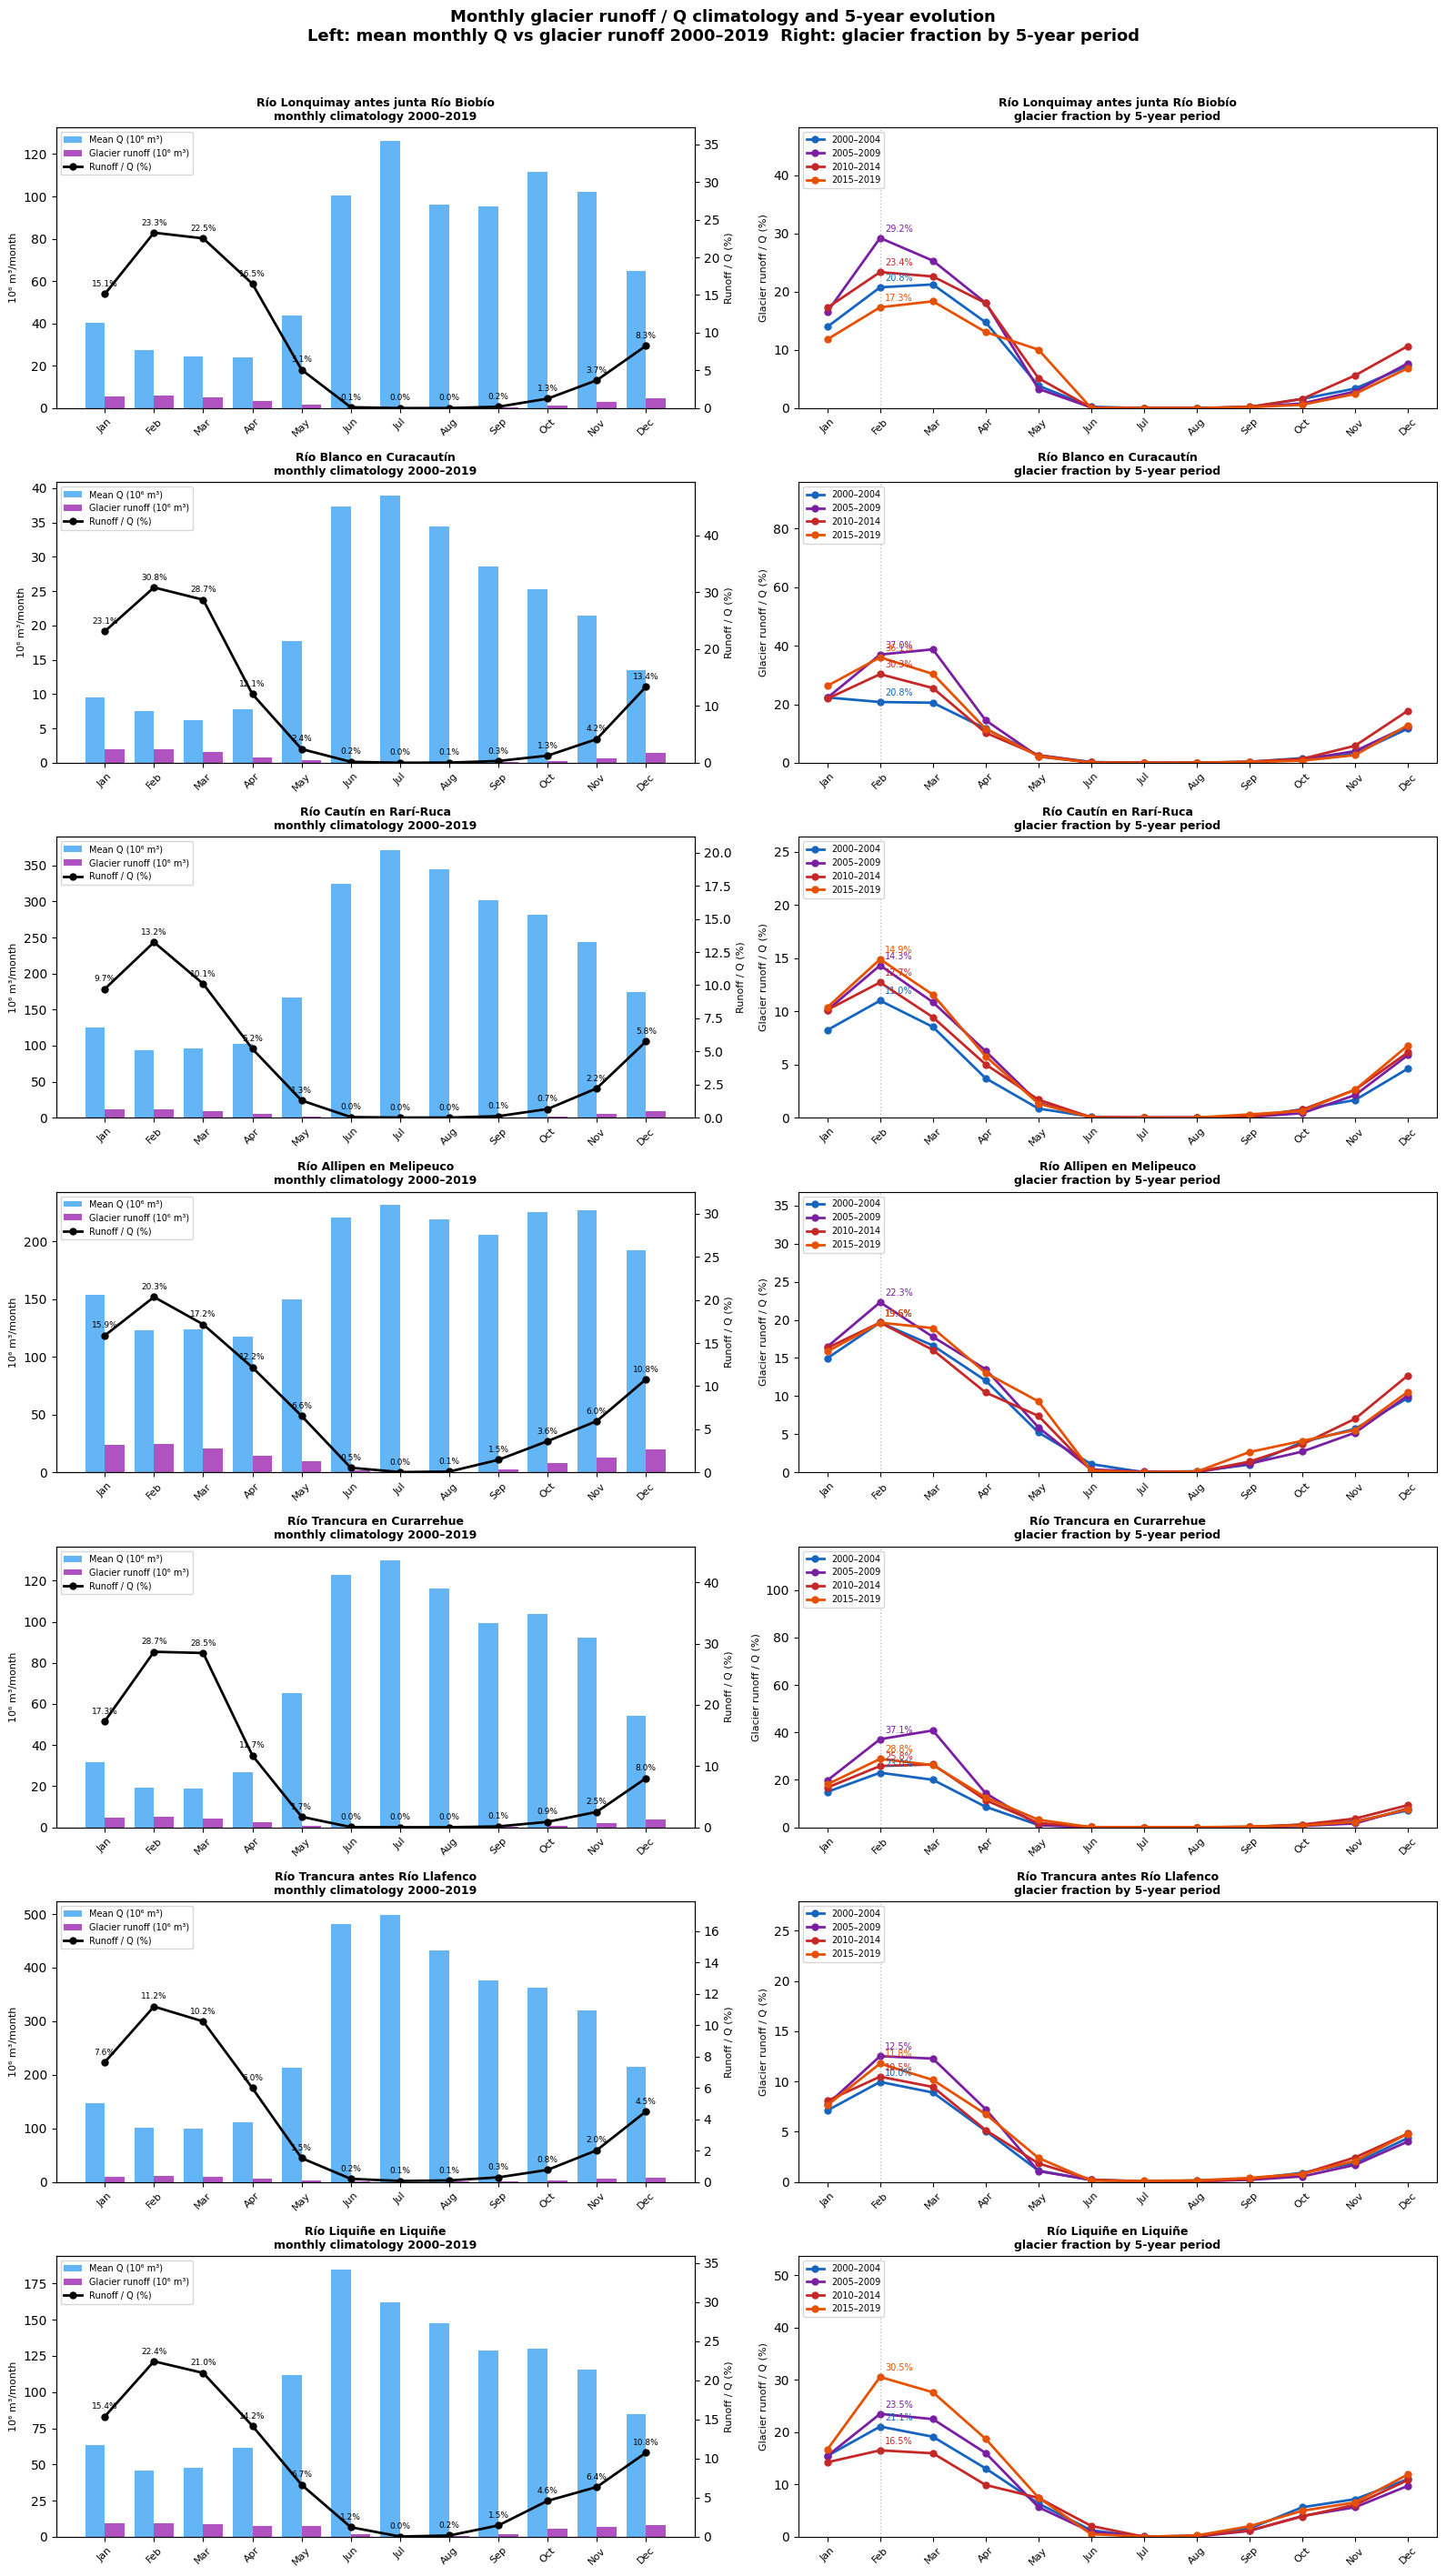

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/all_basins_monthly_climatology.png


In [15]:
"""Multi-basin version of Allipen Cell 6 — climatology and 5-yr evolution for all basins."""

periods = {
    '2000–2004': (2000, 2004),
    '2005–2009': (2005, 2009),
    '2010–2014': (2010, 2014),
    '2015–2019': (2015, 2019),
}
period_colors = ['#1565C0', '#7B1FA2', '#C62828', '#E65100']
months = np.arange(1, 13)

valid = [(gid, res) for gid, res in RESULTS.items() if res is not None]

fig, axes = plt.subplots(len(valid), 2, figsize=(16, 4 * len(valid)))
fig.suptitle(
    'Monthly glacier runoff / Q climatology and 5-year evolution\n'
    'Left: mean monthly Q vs glacier runoff 2000–2019  '
    'Right: glacier fraction by 5-year period',
    fontsize=13, fontweight='bold', y=1.01)

for row, (gauge_id, res) in enumerate(valid):
    basin    = res['basin_name']
    q_mon    = res['q_monthly']
    run_mon  = res['runoff_monthly']
    frac_mon = res['frac_runoff_mon']

    # Restrict to 2000–2019
    mask  = (frac_mon.index.year >= 2000) & (frac_mon.index.year <= 2019)
    q_p   = q_mon[mask]
    run_p = run_mon[mask]
    frac_p = frac_mon[mask]

    # ── Left: climatology ─────────────────────────────────────────────────
    ax1  = axes[row, 0]
    ax1b = ax1.twinx()

    q_clim    = q_p.groupby(q_p.index.month).mean()
    run_clim  = run_p.groupby(run_p.index.month).mean()
    frac_clim = frac_p.groupby(frac_p.index.month).mean()

    ax1.bar(months - 0.2, q_clim.values   / 1e6, width=0.4,
            color=C_Q,    alpha=0.7, label='Mean Q (10⁶ m³)')
    ax1.bar(months + 0.2, run_clim.values  / 1e6, width=0.4,
            color=C_MELT, alpha=0.8, label='Glacier runoff (10⁶ m³)')
    ax1b.plot(months, frac_clim.values, '-o', color='black',
              ms=5, lw=2, label='Runoff / Q (%)')

    for m, f in zip(months, frac_clim.values):
        ax1b.annotate(f'{f:.1f}%', xy=(m, f), xytext=(0, 6),
                      textcoords='offset points', ha='center',
                      fontsize=6.5, color='black')

    ax1.set_xticks(months)
    ax1.set_xticklabels(MONTH_NAMES, fontsize=8, rotation=45)
    ax1.set_ylabel('10⁶ m³/month', fontsize=8)
    ax1b.set_ylabel('Runoff / Q (%)', fontsize=8)
    ax1b.set_ylim(0, frac_clim.max() * 1.6)
    ax1.set_title(f'{basin}\nmonthly climatology 2000–2019',
                  fontsize=9, fontweight='bold')
    l1, lb1 = ax1.get_legend_handles_labels()
    l2, lb2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1+l2, lb1+lb2, fontsize=7, loc='upper left')

    # ── Right: 5-yr periods ───────────────────────────────────────────────
    ax2 = axes[row, 1]

    for (label, (y0, y1)), color in zip(periods.items(), period_colors):
        pmask      = (frac_p.index.year >= y0) & (frac_p.index.year <= y1)
        frac_per   = frac_p[pmask].groupby(frac_p[pmask].index.month).mean()
        ax2.plot(months, frac_per.reindex(months).values, '-o',
                 color=color, lw=2, ms=5, label=label)
        feb_val = frac_per.get(2, np.nan)
        if not np.isnan(feb_val):
            ax2.annotate(f'{feb_val:.1f}%', xy=(2, feb_val),
                         xytext=(4, 5), textcoords='offset points',
                         fontsize=7, color=color)

    ax2.set_xticks(months)
    ax2.set_xticklabels(MONTH_NAMES, fontsize=8, rotation=45)
    ax2.set_ylabel('Glacier runoff / Q (%)', fontsize=8)
    ax2.set_ylim(0, frac_p.groupby(frac_p.index.month).max().max() * 1.4)
    ax2.set_title(f'{basin}\nglacier fraction by 5-year period',
                  fontsize=9, fontweight='bold')
    ax2.axvline(2, color='gray', ls=':', lw=1, alpha=0.5)
    ax2.legend(fontsize=7, loc='upper left')

plt.tight_layout()
out = f'{OUT_DIR}/all_basins_monthly_climatology.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

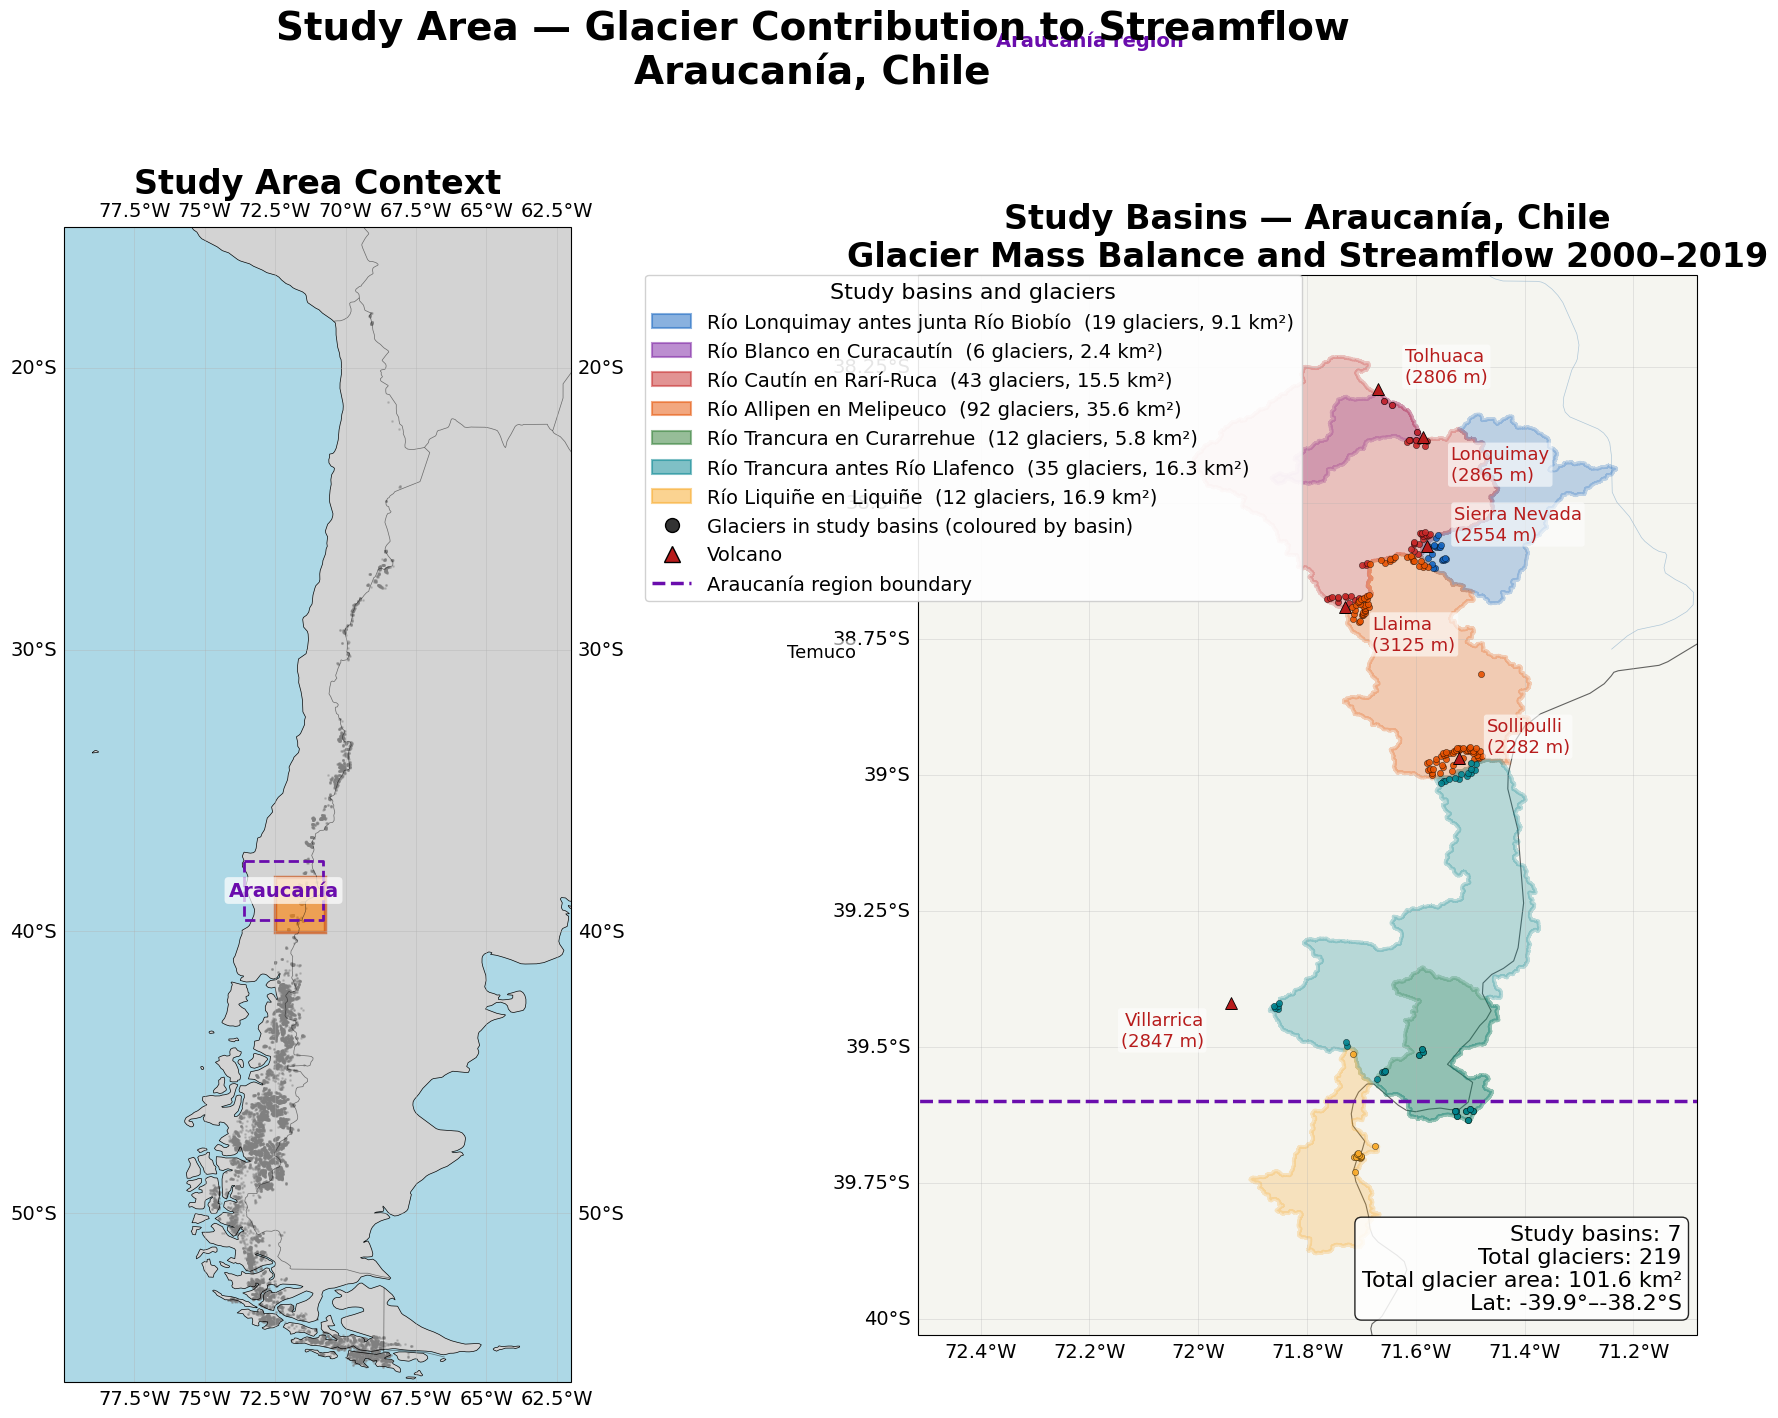

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/study_area_map.png


In [19]:
"""
Study area map — WA1 glaciers + CAMELS basin polygons + volcanoes + cities
"""

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import requests
import io

# ── Volcanoes ─────────────────────────────────────────────────────────────
VOLCANOES = [
    ("Llaima",        -71.730, -38.692, 3125),
    ("Sierra Nevada", -71.580, -38.580, 2554),
    ("Tolhuaca",      -71.670, -38.290, 2806),
    ("Lonquimay",     -71.586, -38.380, 2865),
    ("Sollipulli",    -71.520, -38.970, 2282),
    ("Villarrica",    -71.940, -39.420, 2847),
]
VOL_OFF = {
    "Llaima":        ( 0.05, -0.05, "left"),
    "Sierra Nevada": ( 0.05,  0.04, "left"),
    "Tolhuaca":      ( 0.05,  0.04, "left"),
    "Lonquimay":     ( 0.05, -0.05, "left"),
    "Sollipulli":    ( 0.05,  0.04, "left"),
    "Villarrica":    (-0.05, -0.05, "right"),
}

# ── Cities ────────────────────────────────────────────────────────────────
CITIES = [
    ("Temuco", -72.590, -38.735, True, -0.04, -0.04, "right"),
]

# ── Load RGI glaciers ─────────────────────────────────────────────────────
datos_rgi = pd.read_csv(
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/'
    'files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv')

gdf = gpd.GeoDataFrame(
    datos_rgi,
    geometry=gpd.points_from_xy(datos_rgi.CenLon, datos_rgi.CenLat),
    crs='EPSG:4326')

wa1 = gdf[gdf['Cluster'] == 'WA1']

# ── Load CAMELS basin polygons ────────────────────────────────────────────
basin_gdfs = {}
for gauge_id, res in RESULTS.items():
    if res is None:
        continue
    shp = f'{CAMELS_BASE}/camels_cl_{gauge_id}/polygon/polygon.shp'
    basin_gdfs[gauge_id] = gpd.read_file(shp).to_crs('EPSG:4326')
    basin_gdfs[gauge_id]['gauge_id']   = gauge_id
    basin_gdfs[gauge_id]['basin_name'] = res['basin_name']

basin_colors = [
    '#1565C0', '#7B1FA2', '#C62828', '#E65100',
    '#2E7D32', '#00838F', '#F9A825'
]
gauge_ids = list(basin_gdfs.keys())

# ── Map extent ────────────────────────────────────────────────────────────
all_basins = gpd.GeoDataFrame(
    pd.concat(basin_gdfs.values(), ignore_index=True), crs='EPSG:4326')
bounds        = all_basins.total_bounds
lon_pad_left  = 0.5
lon_pad_right = 0.15
lat_pad       = 0.15
lon_min = bounds[0] - lon_pad_left
lon_max = bounds[2] + lon_pad_right
lat_min = bounds[1] - lat_pad
lat_max = bounds[3] + lat_pad

# ── Araucanía region boundary (approximate polygon) ───────────────────────
# Araucanía region spans roughly 37.5°S–39.6°S, 70.8°W–73.6°W
from shapely.geometry import Polygon
araucania_approx = Polygon([
    (-73.6, -37.5), (-70.8, -37.5),
    (-70.8, -39.6), (-73.6, -39.6),
    (-73.6, -37.5)
])
araucania_gdf = gpd.GeoDataFrame(
    {'name': ['Araucanía']},
    geometry=[araucania_approx],
    crs='EPSG:4326'
)

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))

# ── Panel 1: Chile context ────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([-80, -62, -56, -15], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND,      facecolor='lightgray', edgecolor='none')
ax1.add_feature(cfeature.OCEAN,     facecolor='lightblue')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS,   linewidth=0.5, alpha=0.5)

ax1.scatter(gdf.CenLon, gdf.CenLat,
            s=1, c='gray', alpha=0.3,
            transform=ccrs.PlateCarree())

# Araucanía outline on panel 1
ax1.add_geometries(
    araucania_gdf.geometry,
    crs=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='#6a0dad', linewidth=2.0,
    linestyle='--', zorder=6)
ax1.text(-72.2, -38.55, 'Araucanía', transform=ccrs.PlateCarree(),
         fontsize=14, color='#6a0dad', fontweight='bold',
         ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                   alpha=0.7, edgecolor='none'),
         zorder=7)

ax1.add_patch(Rectangle(
    xy=(bounds[0] - 0.5, bounds[1] - lat_pad),
    width=(bounds[2] - bounds[0]) + 1.0,
    height=(bounds[3] - bounds[1]) + lat_pad * 2,
    facecolor='#ff7f00', alpha=0.6,
    edgecolor='#cc4400', linewidth=2.5,
    transform=ccrs.PlateCarree()))

gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl1.xlabel_style = {'size': 14}
gl1.ylabel_style = {'size': 14}
ax1.set_title('Study Area Context', fontsize=24, fontweight='bold')

# ── Panel 2: Study area detail ────────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max],
               crs=ccrs.PlateCarree())

ax2.add_feature(cfeature.LAND,      facecolor='#f5f5f0',
                edgecolor='black',  linewidth=0.5)
ax2.add_feature(cfeature.OCEAN,     facecolor='#d0e8f0')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS,   linewidth=0.8, alpha=0.6)
ax2.add_feature(cfeature.RIVERS,    linewidth=0.5,
                edgecolor='steelblue', alpha=0.4)

# Araucanía outline on panel 2
ax2.add_geometries(
    araucania_gdf.geometry,
    crs=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='#6a0dad', linewidth=2.5,
    linestyle='--', zorder=6)
ax2.text(-72.2, -37.65, 'Araucanía region', transform=ccrs.PlateCarree(),
         fontsize=14, color='#6a0dad', fontweight='bold',
         ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                   alpha=0.7, edgecolor='none'),
         zorder=7)

# ── Basin polygons ────────────────────────────────────────────────────────
for i, gauge_id in enumerate(gauge_ids):
    gdf_basin = basin_gdfs[gauge_id]
    color     = basin_colors[i % len(basin_colors)]
    ax2.add_geometries(
        gdf_basin.geometry,
        crs=ccrs.PlateCarree(),
        facecolor=color, alpha=0.25,
        edgecolor=color, linewidth=2.5)

# ── Glaciers inside study basins (coloured by basin) ─────────────────────
for i, gauge_id in enumerate(gauge_ids):
    rgi_ids  = GAUGE_INFO[gauge_id]['rgi_ids']
    gl_basin = wa1[wa1['RGIId'].isin(rgi_ids)]
    color    = basin_colors[i % len(basin_colors)]
    ax2.scatter(gl_basin.CenLon, gl_basin.CenLat,
                s=20, c=color, alpha=0.9,
                transform=ccrs.PlateCarree(),
                edgecolors='black', linewidths=0.3,
                zorder=5)

# ── Volcanoes ─────────────────────────────────────────────────────────────
for name, lon, lat, elev in VOLCANOES:
    dx, dy, ha = VOL_OFF[name]
    ax2.plot(lon, lat, marker='^', color='#B71C1C', ms=8,
             mec='black', mew=0.6,
             transform=ccrs.PlateCarree(), zorder=8)
    ax2.text(lon + dx, lat + dy, f'{name}\n({elev} m)',
             transform=ccrs.PlateCarree(),
             fontsize=13, ha=ha, va='center', color='#B71C1C',
             bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                       alpha=0.6, edgecolor='none'),
             zorder=9)

# ── Cities ────────────────────────────────────────────────────────────────
for name, lon, lat, capital, dx, dy, ha in CITIES:
    ax2.plot(lon, lat, marker='*', color='black', ms=10,
             mec='black', mew=0.6,
             transform=ccrs.PlateCarree(), zorder=8)
    ax2.text(lon + dx, lat + dy, name,
             transform=ccrs.PlateCarree(),
             fontsize=13, ha=ha, va='center', color='black',
             bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                       alpha=0.6, edgecolor='none'),
             zorder=9)

# ── Combined legend ───────────────────────────────────────────────────────
basin_legend = []
for i, gauge_id in enumerate(gauge_ids):
    color = basin_colors[i % len(basin_colors)]
    name  = RESULTS[gauge_id]['basin_name']
    n_gl  = GAUGE_INFO[gauge_id]['n_glaciers']
    area  = GAUGE_INFO[gauge_id]['glacier_area_km2']
    basin_legend.append(mpatches.Patch(
        facecolor=color, alpha=0.5,
        edgecolor=color, linewidth=1.5,
        label=f'{name}  ({n_gl} glaciers, {area:.1f} km²)'))

glacier_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#333333', markersize=10,
           markeredgecolor='black',
           label='Glaciers in study basins (coloured by basin)'),
]

volcano_legend = [
    Line2D([0], [0], marker='^', color='w',
           markerfacecolor='#B71C1C', markersize=12,
           markeredgecolor='black', label='Volcano'),
]

araucania_legend = [
    Line2D([0], [0], color='#6a0dad', linewidth=2.5,
           linestyle='--', label='Araucanía region boundary'),
]

ax2.legend(handles=basin_legend + glacier_legend + volcano_legend + araucania_legend,
           fontsize=14, framealpha=0.9,
           title='Study basins and glaciers', title_fontsize=16,
           loc='upper left',
           bbox_to_anchor=(-0.35, 1.0),
           borderaxespad=0)

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4)
gl2.top_labels    = False
gl2.right_labels  = False
gl2.xlabel_style  = {'size': 14}
gl2.ylabel_style  = {'size': 14}
ax2.set_title('Study Basins — Araucanía, Chile\n'
              'Glacier Mass Balance and Streamflow 2000–2019',
              fontsize=24, fontweight='bold')

# ── Stats box ─────────────────────────────────────────────────────────────
n_glaciers_total = sum(GAUGE_INFO[g]['n_glaciers']
                       for g in gauge_ids if GAUGE_INFO.get(g))
area_total       = sum(GAUGE_INFO[g]['glacier_area_km2']
                       for g in gauge_ids if GAUGE_INFO.get(g))
stats = (f'Study basins: {len(gauge_ids)}\n'
         f'Total glaciers: {n_glaciers_total}\n'
         f'Total glacier area: {area_total:.1f} km²\n'
         f'Lat: {bounds[1]:.1f}°–{bounds[3]:.1f}°S')
ax2.text(0.98, 0.02, stats,
         transform=ax2.transAxes, fontsize=16,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.suptitle('Study Area — Glacier Contribution to Streamflow\n'
             'Araucanía, Chile',
             fontsize=28, fontweight='bold', y=1.01)
plt.tight_layout()

out = f'{OUT_DIR}/study_area_map.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

Araucanía rows found: 1


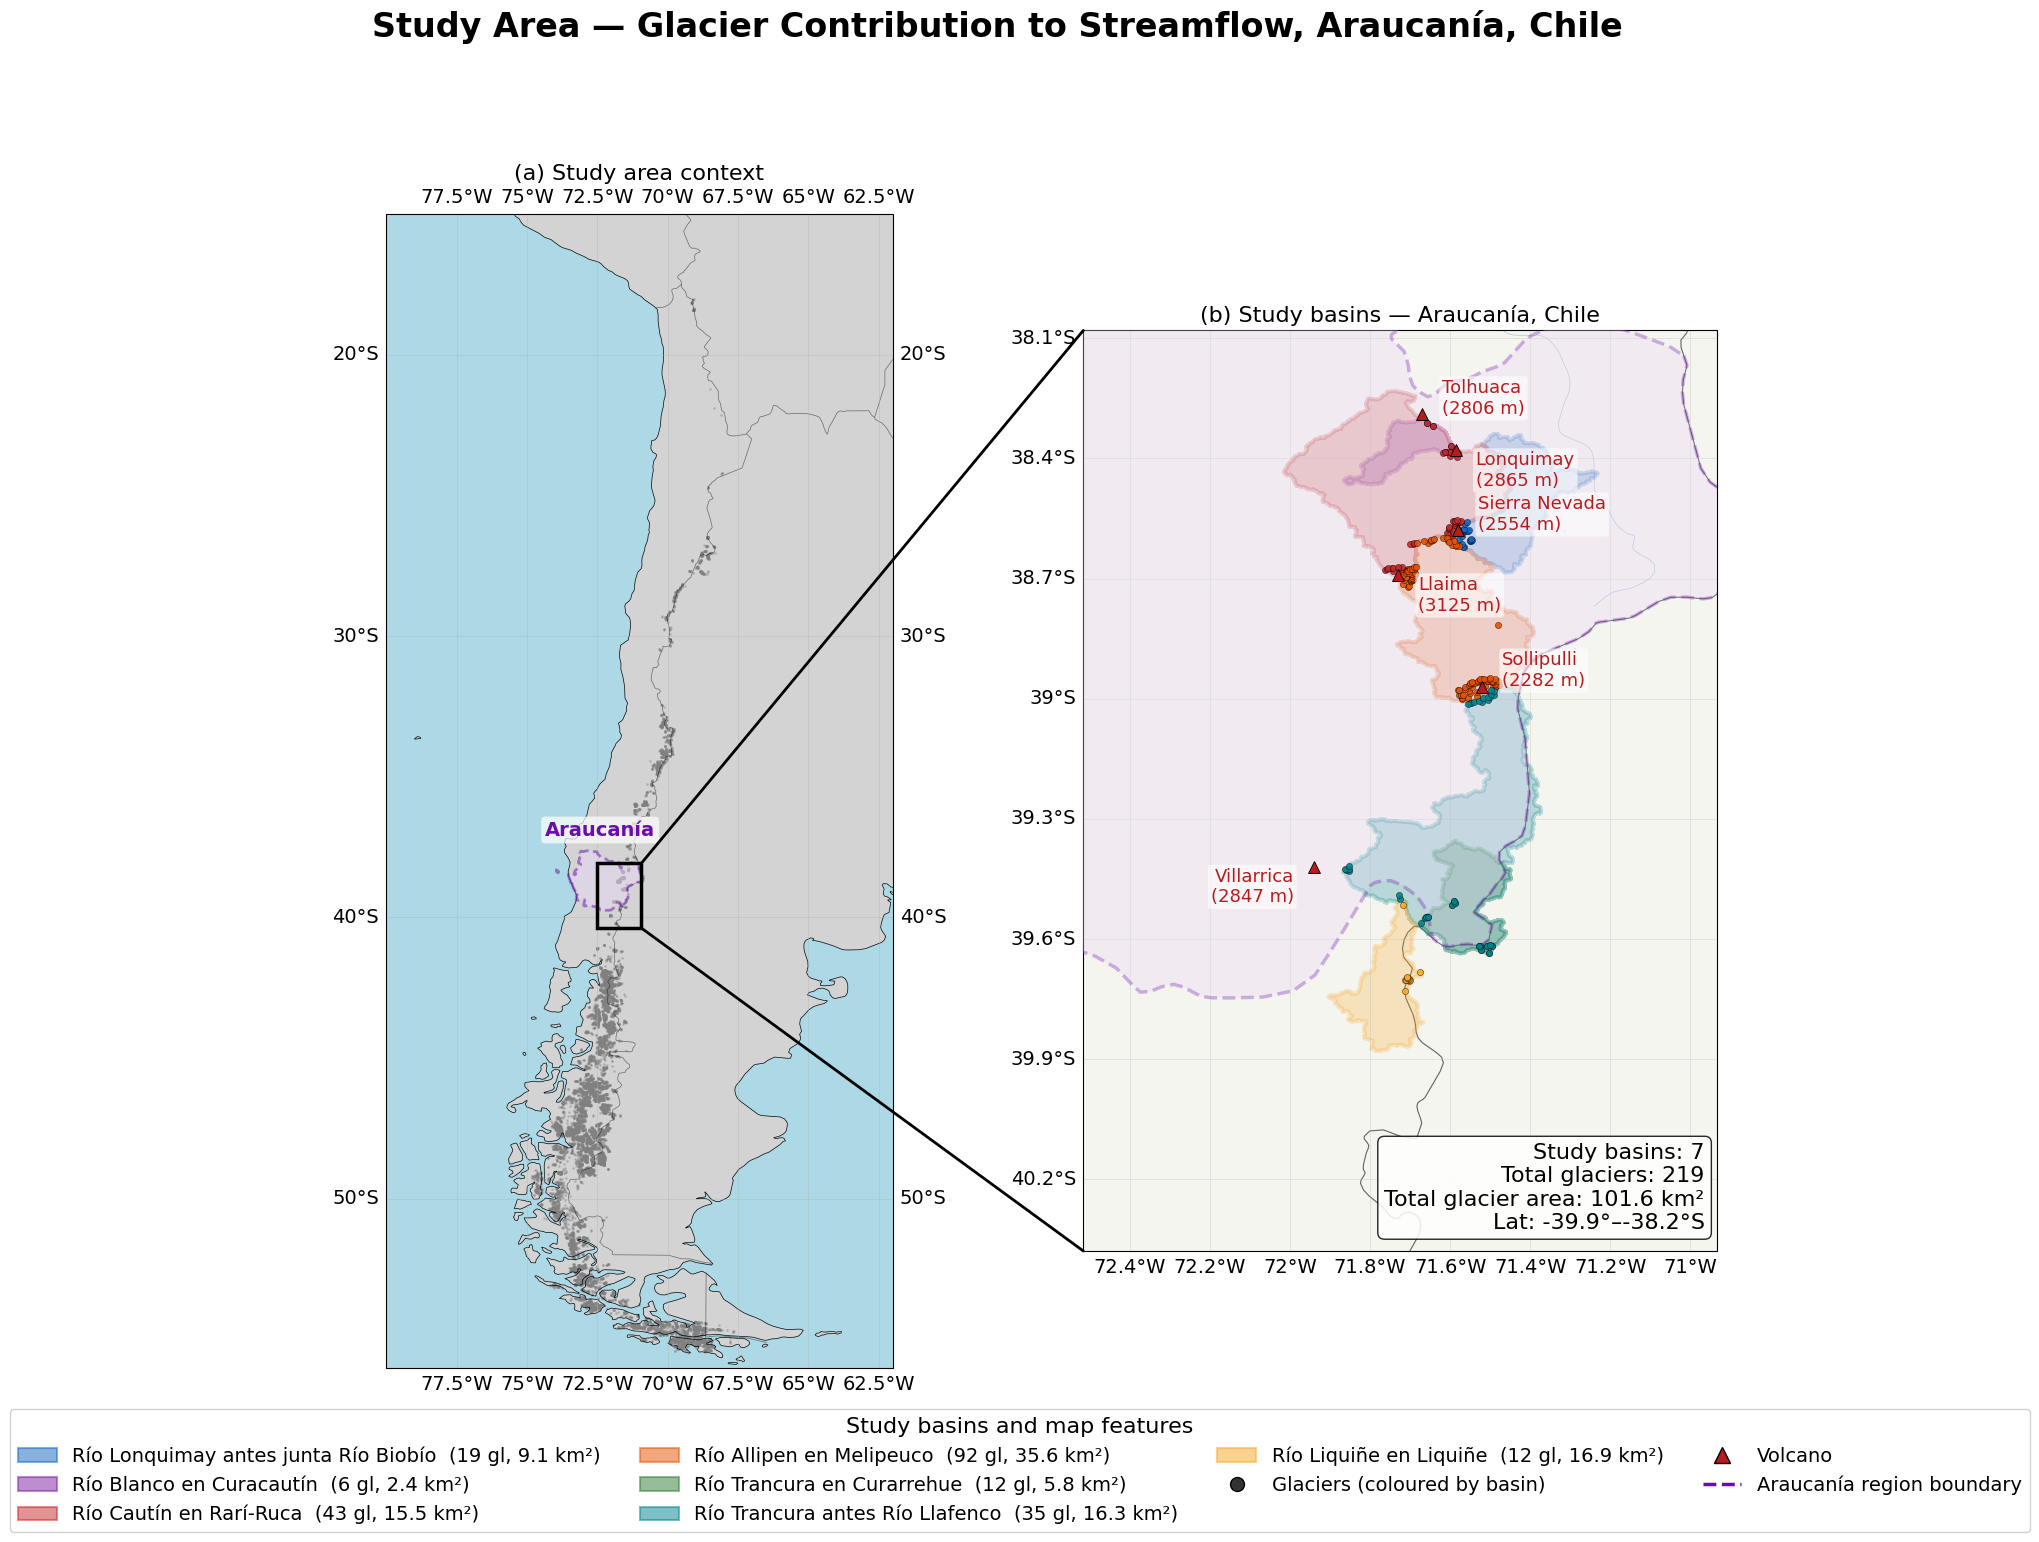

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/MultiBasin_Output/study_area_map.png


In [23]:
"""
Study area map — WA1 glaciers + CAMELS basin polygons + volcanoes + cities
"""

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, ConnectionPatch
import cartopy.io.shapereader as shpreader

# ── Volcanoes ─────────────────────────────────────────────────────────────
VOLCANOES = [
    ("Llaima",        -71.730, -38.692, 3125),
    ("Sierra Nevada", -71.580, -38.580, 2554),
    ("Tolhuaca",      -71.670, -38.290, 2806),
    ("Lonquimay",     -71.586, -38.380, 2865),
    ("Sollipulli",    -71.520, -38.970, 2282),
    ("Villarrica",    -71.940, -39.420, 2847),
]
VOL_OFF = {
    "Llaima":        ( 0.05, -0.05, "left"),
    "Sierra Nevada": ( 0.05,  0.04, "left"),
    "Tolhuaca":      ( 0.05,  0.04, "left"),
    "Lonquimay":     ( 0.05, -0.05, "left"),
    "Sollipulli":    ( 0.05,  0.04, "left"),
    "Villarrica":    (-0.05, -0.05, "right"),
}

# ── Load RGI glaciers ─────────────────────────────────────────────────────
datos_rgi = pd.read_csv(
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/'
    'files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv')

gdf = gpd.GeoDataFrame(
    datos_rgi,
    geometry=gpd.points_from_xy(datos_rgi.CenLon, datos_rgi.CenLat),
    crs='EPSG:4326')

wa1 = gdf[gdf['Cluster'] == 'WA1']

# ── Load Araucanía boundary ───────────────────────────────────────────────
shp = shpreader.natural_earth(resolution='10m', category='cultural',
                              name='admin_1_states_provinces')
ne = gpd.read_file(shp)
araucania_gdf = ne[(ne['admin'] == 'Chile') & (ne['name'] == 'Araucanía')].to_crs('EPSG:4326')
if len(araucania_gdf) == 0:
    araucania_gdf = ne[(ne['admin'] == 'Chile') &
                       (ne['name'].str.contains('raucan', case=False))].to_crs('EPSG:4326')
print(f"Araucanía rows found: {len(araucania_gdf)}")

# ── Load CAMELS basin polygons ────────────────────────────────────────────
basin_gdfs = {}
for gauge_id, res in RESULTS.items():
    if res is None:
        continue
    shp_path = f'{CAMELS_BASE}/camels_cl_{gauge_id}/polygon/polygon.shp'
    basin_gdfs[gauge_id] = gpd.read_file(shp_path).to_crs('EPSG:4326')
    basin_gdfs[gauge_id]['gauge_id']   = gauge_id
    basin_gdfs[gauge_id]['basin_name'] = res['basin_name']

basin_colors = [
    '#1565C0', '#7B1FA2', '#C62828', '#E65100',
    '#2E7D32', '#00838F', '#F9A825'
]
gauge_ids = list(basin_gdfs.keys())

# ── Map extents ───────────────────────────────────────────────────────────
all_basins = gpd.GeoDataFrame(
    pd.concat(basin_gdfs.values(), ignore_index=True), crs='EPSG:4326')
bounds        = all_basins.total_bounds
lon_pad_left  = 0.5
lon_pad_right = 0.3
lat_pad_top   = 0.15
lat_pad_bot   = 0.5
lon_min = bounds[0] - lon_pad_left
lon_max = bounds[2] + lon_pad_right
lat_min = bounds[1] - lat_pad_bot
lat_max = bounds[3] + lat_pad_top

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 17))
gs  = fig.add_gridspec(2, 2, height_ratios=[11, 1], hspace=0.08)

# ── Panel 1: Chile context ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax1.set_extent([-80, -62, -56, -15], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND,      facecolor='lightgray', edgecolor='none')
ax1.add_feature(cfeature.OCEAN,     facecolor='lightblue')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS,   linewidth=0.5, alpha=0.5)

ax1.scatter(gdf.CenLon, gdf.CenLat,
            s=1, c='gray', alpha=0.3,
            transform=ccrs.PlateCarree())

# Araucanía outline — panel 1
if len(araucania_gdf) > 0:
    ax1.add_geometries(
        araucania_gdf.geometry,
        crs=ccrs.PlateCarree(),
        facecolor='#e8d5f5', alpha=0.5,
        edgecolor='#6a0dad', linewidth=2.0,
        linestyle='--', zorder=6)
    bounds_ara = araucania_gdf.total_bounds
    ax1.text(
        (bounds_ara[0] + bounds_ara[2]) / 2,
        bounds_ara[3] + 0.4,
        'Araucanía',
        transform=ccrs.PlateCarree(),
        fontsize=14, color='#6a0dad', fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  alpha=0.7, edgecolor='none'),
        zorder=7)

# Bold black inset box (no fill) on panel 1
ax1.add_patch(Rectangle(
    xy=(lon_min, lat_min),
    width=lon_max - lon_min,
    height=lat_max - lat_min,
    facecolor='none',
    edgecolor='black', linewidth=2.5,
    transform=ccrs.PlateCarree(),
    zorder=8))

gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl1.xlabel_style = {'size': 14}
gl1.ylabel_style = {'size': 14}
ax1.set_title('(a) Study area context', fontsize=16, fontweight='normal', pad=6)

# ── Panel 2: Study area detail ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max],
               crs=ccrs.PlateCarree())

ax2.add_feature(cfeature.LAND,      facecolor='#f5f5f0',
                edgecolor='black',  linewidth=0.5)
ax2.add_feature(cfeature.OCEAN,     facecolor='#d0e8f0')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS,   linewidth=0.8, alpha=0.6)
ax2.add_feature(cfeature.RIVERS,    linewidth=0.5,
                edgecolor='steelblue', alpha=0.4)

# Araucanía outline — panel 2
if len(araucania_gdf) > 0:
    ax2.add_geometries(
        araucania_gdf.geometry,
        crs=ccrs.PlateCarree(),
        facecolor='#e8d5f5', alpha=0.3,
        edgecolor='#6a0dad', linewidth=2.5,
        linestyle='--', zorder=4)

# Basin polygons
for i, gauge_id in enumerate(gauge_ids):
    gdf_basin = basin_gdfs[gauge_id]
    color     = basin_colors[i % len(basin_colors)]
    ax2.add_geometries(
        gdf_basin.geometry,
        crs=ccrs.PlateCarree(),
        facecolor=color, alpha=0.25,
        edgecolor=color, linewidth=2.5)

# Glaciers
for i, gauge_id in enumerate(gauge_ids):
    rgi_ids  = GAUGE_INFO[gauge_id]['rgi_ids']
    gl_basin = wa1[wa1['RGIId'].isin(rgi_ids)]
    color    = basin_colors[i % len(basin_colors)]
    ax2.scatter(gl_basin.CenLon, gl_basin.CenLat,
                s=20, c=color, alpha=0.9,
                transform=ccrs.PlateCarree(),
                edgecolors='black', linewidths=0.3,
                zorder=5)

# Volcanoes
for name, lon, lat, elev in VOLCANOES:
    dx, dy, ha = VOL_OFF[name]
    ax2.plot(lon, lat, marker='^', color='#B71C1C', ms=8,
             mec='black', mew=0.6,
             transform=ccrs.PlateCarree(), zorder=8)
    ax2.text(lon + dx, lat + dy, f'{name}\n({elev} m)',
             transform=ccrs.PlateCarree(),
             fontsize=13, ha=ha, va='center', color='#B71C1C',
             bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                       alpha=0.6, edgecolor='none'),
             zorder=9)

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4)
gl2.top_labels   = False
gl2.right_labels = False
gl2.xlabel_style = {'size': 14}
gl2.ylabel_style = {'size': 14}
ax2.set_title('(b) Study basins — Araucanía, Chile', fontsize=16,
              fontweight='normal', pad=6)

# Stats box
n_glaciers_total = sum(GAUGE_INFO[g]['n_glaciers']
                       for g in gauge_ids if GAUGE_INFO.get(g))
area_total       = sum(GAUGE_INFO[g]['glacier_area_km2']
                       for g in gauge_ids if GAUGE_INFO.get(g))
stats = (f'Study basins: {len(gauge_ids)}\n'
         f'Total glaciers: {n_glaciers_total}\n'
         f'Total glacier area: {area_total:.1f} km²\n'
         f'Lat: {bounds[1]:.1f}°–{bounds[3]:.1f}°S')
ax2.text(0.98, 0.02, stats,
         transform=ax2.transAxes, fontsize=16,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# ── Leader lines: top-right and bottom-right corners of box → panel B ─────
# Both endpoints expressed in data coords on ax1 and axes coords on ax2.
# We connect the two right-hand corners of the inset box to the
# corresponding top-left and bottom-left corners of panel B.
fig.canvas.draw()   # needed so ax transforms are finalised

corner_pairs = [
    # (ax1 data lon/lat,   ax2 axes x/y)
    ((lon_max, lat_max),  (0.0, 1.0)),   # top-right box  → top-left  panel B
    ((lon_max, lat_min),  (0.0, 0.0)),   # bot-right box  → bot-left  panel B
]
for (data_xy, axB_xy) in corner_pairs:
    con = ConnectionPatch(
        xyA=data_xy,   coordsA=ax1.transData,
        xyB=axB_xy,    coordsB=ax2.transAxes,
        arrowstyle='-', color='black', linewidth=2.0,
        linestyle='solid', zorder=10)
    fig.add_artist(con)

# ── Legend ────────────────────────────────────────────────────────────────
ax_leg = fig.add_subplot(gs[1, :])
ax_leg.axis('off')

basin_legend = []
for i, gauge_id in enumerate(gauge_ids):
    color = basin_colors[i % len(basin_colors)]
    name  = RESULTS[gauge_id]['basin_name']
    n_gl  = GAUGE_INFO[gauge_id]['n_glaciers']
    area  = GAUGE_INFO[gauge_id]['glacier_area_km2']
    basin_legend.append(mpatches.Patch(
        facecolor=color, alpha=0.5,
        edgecolor=color, linewidth=1.5,
        label=f'{name}  ({n_gl} gl, {area:.1f} km²)'))

extra_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#333333', markersize=10,
           markeredgecolor='black',
           label='Glaciers (coloured by basin)'),
    Line2D([0], [0], marker='^', color='w',
           markerfacecolor='#B71C1C', markersize=12,
           markeredgecolor='black', label='Volcano'),
    Line2D([0], [0], color='#6a0dad', linewidth=2.5,
           linestyle='--', label='Araucanía region boundary'),
]

ax_leg.legend(
    handles=basin_legend + extra_legend,
    fontsize=14, framealpha=0.9,
    title='Study basins and map features', title_fontsize=16,
    loc='center', ncol=4,
    borderaxespad=0)

plt.suptitle('Study Area — Glacier Contribution to Streamflow, Araucanía, Chile',
             fontsize=24, fontweight='bold', y=1.0)
plt.tight_layout()

out = f'{OUT_DIR}/study_area_map.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## key results: 

In [17]:
valid = {gid: res for gid, res in RESULTS.items() if res is not None}

mean_annual = np.mean([res['mean_frac_runoff'] for res in valid.values()])

mean_feb = np.mean([
    res['frac_runoff_mon'][res['frac_runoff_mon'].index.month == 2].mean()
    for res in valid.values()
])

mean_megadrought = np.mean([
    res['frac_runoff_ann'].loc[2015:2019].mean()
    for res in valid.values()
    if len(res['frac_runoff_ann'].loc[2015:2019]) > 0
])

# Basin with highest mean contribution during megadrought
max_megadrought_basin = {
    gid: res['frac_runoff_ann'].loc[2015:2019].mean()
    for gid, res in valid.items()
    if len(res['frac_runoff_ann'].loc[2015:2019]) > 0
}
max_gid_md   = max(max_megadrought_basin, key=max_megadrought_basin.get)
max_md_val   = max_megadrought_basin[max_gid_md]
max_md_basin = RESULTS[max_gid_md]['basin_name']

# Single peak year across all basins
contributions_2019 = {
    gid: res['frac_runoff_ann'].loc[2019]
    for gid, res in valid.items()
    if 2019 in res['frac_runoff_ann'].index
}
max_yr_gid   = max(contributions_2019, key=contributions_2019.get)
max_yr_val   = contributions_2019[max_yr_gid]
max_yr_basin = RESULTS[max_yr_gid]['basin_name']

print(f'Cross-basin mean annual contribution             : {mean_annual:.1f}%')
print(f'Cross-basin mean February contribution           : {mean_feb:.1f}%')
print(f'Cross-basin mean contribution 2015-2019          : {mean_megadrought:.1f}%')
print(f'Highest mean contribution 2015-2019              : {max_md_val:.1f}% ({max_md_basin})')
print(f'Single highest annual contribution (any yr/basin): {max_yr_val:.1f}% ({max_yr_basin}, 2019)')

Cross-basin mean annual contribution             : 5.5%
Cross-basin mean February contribution           : 21.4%
Cross-basin mean contribution 2015-2019          : 10.7%
Highest mean contribution 2015-2019              : 21.0% (Río Allipen en Melipeuco)
Single highest annual contribution (any yr/basin): 44.3% (Río Blanco en Curacautín, 2019)


In [18]:
"""Annual and seasonal summary tables for all 7 basins."""

for gauge_id, res in RESULTS.items():
    if res is None:
        continue

    basin_name  = res['basin_name']
    q_ann       = res['q_annual']
    melt_ann    = res['melt_annual']
    runoff_ann  = res['runoff_annual']
    frac_melt   = res['frac_melt_ann']
    frac_runoff = res['frac_runoff_ann']
    q_seas      = res['q_seasonal']
    gl_mon_mean = res['gl_mon_mean']
    frac_seas   = res['frac_runoff_seas']

    print(f'\n{"═"*65}')
    print(f'  {basin_name} ({gauge_id})')
    print(f'{"═"*65}')

    # ── Annual summary ────────────────────────────────────────────────────
    annual = pd.DataFrame({
        'Q_km3':        (q_ann      / 1e9).round(4),
        'Melt_km3':     (melt_ann   / 1e9).round(4),
        'Runoff_km3':   (runoff_ann / 1e9).round(4),
        'Melt_pct':     frac_melt.round(2),
        'Runoff_pct':   frac_runoff.round(2),
    })
    print('\n── Annual Summary ───────────────────────────────────────────')
    print(annual.to_string())

    # ── Seasonal summary ──────────────────────────────────────────────────
    seasonal = pd.DataFrame({
        'Mean_Q_m3':       res['q_seasonal'].values.round(0),
        'Mean_runoff_m3':  res['runoff_seasonal'].values.round(0),
        'Runoff_pct':      frac_seas.values.round(2),
        'Melt_only_pct':   res['frac_melt_seas'].values.round(2),
    }, index=MONTH_NAMES)
    print('\n── Seasonal Summary (mean 2000–2019) ────────────────────────')
    print(seasonal.to_string())

    # ── Key statistics ────────────────────────────────────────────────────
    print(f'\n── Key Statistics ───────────────────────────────────────────')
    print(f'  Basin area         : {res["basin_area_km2"]:.1f} km²')
    print(f'  Glacier area       : {res["glacier_area_km2"]:.1f} km²  '
          f'({res["glacier_pct"]:.1f}% of basin)')
    print(f'  N glaciers         : {res["n_glaciers"]}')
    print(f'  Mean runoff / Q    : {res["mean_frac_runoff"]:.1f}%')
    print(f'  Mean melt-only / Q : {res["mean_frac_melt"]:.1f}%')
    print(f'  Rain on glacier    : {res["mean_frac_runoff"] - res["mean_frac_melt"]:.1f}%  '
          f'(liquid precip on glacier)')
    print(f'  Peak month         : {MONTH_NAMES[frac_seas.values.argmax()]}  '
          f'({frac_seas.values.max():.1f}%)')
    print(f'  Max annual runoff/Q: {res["max_frac_runoff"]:.1f}%  '
          f'({res["max_frac_year"]})')


═════════════════════════════════════════════════════════════════
  Río Lonquimay antes junta Río Biobío (8304001)
═════════════════════════════════════════════════════════════════

── Annual Summary ───────────────────────────────────────────
       Q_km3  Melt_km3  Runoff_km3  Melt_pct  Runoff_pct
2000  0.9435    0.0174      0.0268      1.85        2.85
2001  1.0575    0.0231      0.0320      2.18        3.02
2002  1.0298    0.0196      0.0321      1.90        3.11
2003  0.8045    0.0205      0.0288      2.55        3.57
2004  0.7973    0.0233      0.0336      2.92        4.22
2005  0.9874    0.0199      0.0266      2.01        2.69
2006  1.1877    0.0223      0.0350      1.88        2.95
2007  0.5666    0.0212      0.0278      3.73        4.90
2008  0.7617    0.0277      0.0367      3.63        4.82
2009  0.8677    0.0225      0.0315      2.59        3.63
2010  0.5211    0.0207      0.0283      3.98        5.44
2011  0.6888    0.0241      0.0320      3.49        4.65
2012  0.4788  